# Space is a latent sequence, and replay explores it

### Running Antonov & Dayan's *Exploring replay* experiments on the CSCG theory of the hippocampus

This notebook combines two papers:

| | |
|---|---|
| **Theory** | Raju, Guntupalli, Zhou, Wendelken, Lázaro-Gredilla & George (2024), *Space is a latent sequence: A theory of the hippocampus*, **Science Advances** 10, eadm8470 |
| **Experiments** | Antonov & Dayan (2025), *Exploring replay*, **Nature Communications** 16, 1657 |

---

## Why these two papers need each other

Antonov & Dayan extend Mattar & Daw's normative theory of hippocampal replay to **partially observable** settings. Their agent maintains a belief state $b=\{s, p(\mu)\}$ and schedules Bellman backups by their expected value, $\mathrm{EVB} = \text{Need} \times \text{Gain}$, so that replay computes a policy trading directed exploration off against exploitation. Crucially, though, they assume the agent **has full access to its physical location** $s$; the only thing it is uncertain about is whether barriers are present.

Raju et al. deny exactly that premise. On their account the hippocampus never receives locations at all — only *aliased egocentric sensations*. Identical sensations recur at many places, and a "location" is nothing but a **latent sequential context**: a clone in a clone-structured causal graph (CSCG), learned by EM over action-conditioned sequences. Place fields, on this view, are an artefact of the experimenter's Euclidean plotting convention, not something the agent computes or needs.

So the natural experiment is: **take away the coordinates.** Replace Antonov & Dayan's physical state space with a CSCG clone graph learned from aliased sensations, and re-run every experiment.

> **The question this notebook answers:** does normative replay still work when "space" is only a latent sequence — and where does it break?

---

## What we do

Every replay algorithm here runs on an abstract `GraphMDP` that knows nothing about rows, columns or geometry. We instantiate it **two ways** and run everything side by side:

* **`ground-truth`** — nodes are true maze cells (Antonov & Dayan's assumption)
* **`clone-graph`** — nodes are CSCG clones learned from aliased sensations (the CSCG theory)

---

## Contents

| Part | Content | Reproduces |
|---|---|---|
| **1** | The Tolman maze and its perceptual aliasing | A&D Fig. 3 environment |
| **2** | Learning the cognitive map with a CSCG | Raju Figs. 1–2 |
| **3** | Exploratory replay in Bayesian bandits | A&D Figs. 1–2 |
| **4** | One replay engine, two state spaces | *the bridge* |
| **5** | Exploitative replay is suboptimal | A&D Fig. 3 |
| **6** | Exploratory replay in belief space | A&D Figs. 4–5 |
| **7** | Sequence replay and deep propagation | A&D Fig. 6 |
| **8** | Replay in a blocked corridor; Ólafsdóttir et al. | A&D Fig. 7 |
| **9** | Predictions unique to the combined theory | *new* |

---

**Runtime** ≈ 15–20 min on a free Colab CPU. Set `FAST = True` below for ≈ 5 min.

In [ ]:
#@title Setup
import sys, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.size": 9, "axes.titlesize": 9, "axes.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white",
})

# ---------------------------------------------------------------- CONFIG
FAST = False          # True -> smaller/faster settings, same qualitative results

CFG = dict(
    walk_steps      = 10000 if FAST else 15000,  # CSCG training data
    clones_per_obs  = 12,                        # CSCG capacity (needed for a clean map)
    em_iter         = 100  if FAST else 150,
    vit_iter        = 30   if FAST else 40,
    n_restarts      = 1,
    fig3_steps      = 1000 if FAST else 2000,    # moves per phase in Fig. 3
    horizon         = 6    if FAST else 7,       # belief-tree planning horizon
    seq_events      = 4    if FAST else 8,
)
SEED = 0
np.random.seed(SEED)
print("FAST =", FAST)
print({k: v for k, v in CFG.items()})

FAST = False
{'walk_steps': 15000, 'clones_per_obs': 12, 'em_iter': 150, 'vit_iter': 40, 'n_restarts': 1, 'fig3_steps': 2000, 'horizon': 7, 'seq_events': 8}


### Modules

The next five cells write the implementation to disk, so the notebook is self-contained and the code stays readable. Skip past them on a first pass — the science starts at Part 1.

* `cscg.py` — the clone-structured causal graph (EM, Viterbi-EM, decoding, planning)
* `mazes.py` — the Tolman maze, the T-maze, and aliased sensations
* `replay.py` — belief-space replay: Need, Gain, EVB, single-action and sequence replay
* `bridge.py` — builds the *same* MDP from maze cells or from CSCG clones
* `mab.py` — the bandit belief tree of Part 3
* `plots.py` — figure helpers

In [ ]:
%%writefile cscg.py
"""
Clone-Structured Causal Graph (CSCG)
====================================
Raju, Guntupalli, Zhou, Wendelken, Lazaro-Gredilla & George (2024),
"Space is a latent sequence: A theory of the hippocampus", Sci. Adv. 10, eadm8470.

An action-augmented cloned HMM.  Latent states ("clones") are partitioned into
disjoint blocks, one block per discrete observation, and the emission is
deterministic (a clone emits exactly one observation).  Learning optimises the
action-conditional transition tensor

    T[a, i, j] = P(z_{n+1} = j | z_n = i, a_n = a)

by EM (Baum-Welch), optionally followed by Viterbi (hard) EM, which collapses
the superposition of latent graphs produced by soft EM into a single sparse
graph.

This implementation is *batched*: it trains on many episodes in parallel using
dense matrix products, grouping timesteps by action.  That is far faster than a
per-timestep Python loop and keeps the notebook practical on a free Colab CPU.
"""
import numpy as np


# ==========================================================================
class CSCG:
    """
    Parameters
    ----------
    n_clones : (n_obs,) int array
        Number of clones allocated to each discrete observation ("capacity").
        The model is normally given *excess* capacity; EM uses it to split or
        merge sequential contexts as needed.
    n_actions : int
    pseudocount : float
        Smoothing added to the accumulated count statistics in the M-step so
        that no transition has exactly zero probability.
    """

    def __init__(self, n_clones, n_actions, pseudocount=1e-2, seed=42):
        self.n_clones = np.asarray(n_clones, dtype=np.int64)
        self.n_actions = int(n_actions)
        self.pseudocount = float(pseudocount)
        self.n_obs = len(self.n_clones)
        self.n_states = int(self.n_clones.sum())
        self.state_loc = np.hstack(([0], self.n_clones)).cumsum()
        self.clone_obs = np.repeat(np.arange(self.n_obs), self.n_clones)

        rng = np.random.RandomState(seed)
        T = rng.rand(self.n_actions, self.n_states, self.n_states) + 1e-3
        self.T = T / T.sum(axis=2, keepdims=True)
        self.Pi = np.ones(self.n_states) / self.n_states

    # ---------------------------------------------------------------- utils
    @staticmethod
    def as_episodes(x, a, ep_len=200):
        """Chop a single (obs, action) stream into a batch of episodes."""
        x = np.asarray(x, dtype=np.int64)
        a = np.asarray(a, dtype=np.int64)
        n = (len(x) // ep_len) * ep_len
        return x[:n].reshape(-1, ep_len), a[:n].reshape(-1, ep_len)

    def _mask(self, xt):
        return (self.clone_obs[:, None] == xt[None, :]).astype(np.float64)

    @staticmethod
    def _norm_cols(M):
        s = M.sum(axis=0, keepdims=True)
        s = np.where(s <= 0, 1e-300, s)
        return M / s, s[0]

    def _apply_by_action(self, m, At, transpose):
        out = np.zeros_like(m)
        for act in range(self.n_actions):
            idx = np.flatnonzero(At == act)
            if idx.size == 0:
                continue
            M = self.T[act].T if transpose else self.T[act]
            out[:, idx] = M @ m[:, idx]
        return out

    # ------------------------------------------------------------- forward
    def _forward(self, X, A, store=True):
        B, L = X.shape
        alpha = np.empty((L, self.n_states, B)) if store else None
        log2lik = np.empty((L, B))
        m = self.Pi[:, None] * self._mask(X[:, 0])
        m, s = self._norm_cols(m)
        log2lik[0] = np.log2(s)
        if store:
            alpha[0] = m
        for t in range(1, L):
            m = self._apply_by_action(m, A[:, t - 1], transpose=True)
            m = m * self._mask(X[:, t])
            m, s = self._norm_cols(m)
            log2lik[t] = np.log2(s)
            if store:
                alpha[t] = m
        return log2lik, alpha

    def _backward(self, X, A):
        B, L = X.shape
        beta = np.empty((L, self.n_states, B))
        m, _ = self._norm_cols(self._mask(X[:, L - 1]))
        beta[L - 1] = m
        for t in range(L - 2, -1, -1):
            m = self._apply_by_action(beta[t + 1], A[:, t], transpose=False)
            m = m * self._mask(X[:, t])
            m, _ = self._norm_cols(m)
            beta[t] = m
        return beta

    # ------------------------------------------------------------------ EM
    def learn_em_T(self, X, A, n_iter=100, tol=1e-5, verbose=False):
        """Soft (Baum-Welch) EM on the transition tensor."""
        X, A = np.atleast_2d(X), np.atleast_2d(A)
        B, L = X.shape
        conv, prev = [], np.inf
        for it in range(n_iter):
            log2lik, alpha = self._forward(X, A, store=True)
            beta = self._backward(X, A)
            C = np.zeros_like(self.T)
            for t in range(1, L):
                At = A[:, t - 1]
                for act in range(self.n_actions):
                    idx = np.flatnonzero(At == act)
                    if idx.size == 0:
                        continue
                    Aa = alpha[t - 1][:, idx]
                    Bb = beta[t][:, idx]
                    denom = np.einsum("ib,ij,jb->b", Aa, self.T[act], Bb)
                    denom = np.where(denom <= 0, 1e-300, denom)
                    C[act] += self.T[act] * (Aa @ (Bb / denom).T)
            self._m_step(C)
            bps = float(-log2lik.mean())
            conv.append(bps)
            if verbose and (it % 10 == 0 or it == n_iter - 1):
                print(f"    EM    iter {it:3d}   bits/step = {bps:.5f}")
            if abs(prev - bps) < tol:
                break
            prev = bps
        return np.array(conv)

    # -------------------------------------------------------- Viterbi (MP)
    def _mp_forward(self, X, A, chunk=32):
        B, L = X.shape
        n = self.n_states
        msgs = np.empty((L, n, B))
        back = np.zeros((L, n, B), dtype=np.int32)
        log2lik = np.zeros((L, B))
        m = self.Pi[:, None] * self._mask(X[:, 0])
        m = m / np.maximum(m.max(axis=0, keepdims=True), 1e-300)
        msgs[0] = m
        for t in range(1, L):
            new = np.zeros((n, B))
            arg = np.zeros((n, B), dtype=np.int32)
            At = A[:, t - 1]
            for act in range(self.n_actions):
                idx = np.flatnonzero(At == act)
                if idx.size == 0:
                    continue
                Tact = self.T[act]
                for k in range(0, idx.size, chunk):
                    sub = idx[k : k + chunk]
                    prod = Tact[:, :, None] * m[:, None, sub]
                    new[:, sub] = prod.max(axis=0)
                    arg[:, sub] = prod.argmax(axis=0)
            new = new * self._mask(X[:, t])
            mx = np.maximum(new.max(axis=0, keepdims=True), 1e-300)
            log2lik[t] = np.log2(mx[0])
            m = new / mx
            msgs[t] = m
            back[t] = arg
        return log2lik, msgs, back

    @staticmethod
    def _mp_backtrace(msgs, back):
        L, n, B = msgs.shape
        states = np.zeros((L, B), dtype=np.int64)
        states[L - 1] = msgs[L - 1].argmax(axis=0)
        for t in range(L - 1, 0, -1):
            states[t - 1] = back[t][states[t], np.arange(B)]
        return states

    def learn_viterbi_T(self, X, A, n_iter=50, verbose=False):
        """Hard (Viterbi) EM: consolidates the graph superposition."""
        X, A = np.atleast_2d(X), np.atleast_2d(A)
        B, L = X.shape
        conv, prev = [], -np.inf
        for it in range(n_iter):
            log2lik, msgs, back = self._mp_forward(X, A)
            states = self._mp_backtrace(msgs, back)
            C = np.zeros_like(self.T)
            for t in range(1, L):
                np.add.at(C, (A[:, t - 1], states[t - 1], states[t]), 1.0)
            self._m_step(C)
            score = float(log2lik.mean())
            conv.append(-score)
            if verbose and (it % 10 == 0 or it == n_iter - 1):
                print(f"    VitEM iter {it:3d}   bits/step = {-score:.5f}")
            if score <= prev:
                break
            prev = score
        return np.array(conv)

    def _m_step(self, C):
        T = C + self.pseudocount
        self.T = T / T.sum(axis=2, keepdims=True)

    # ---------------------------------------------------------- inference
    def bps(self, x, a):
        X, A = np.atleast_2d(x), np.atleast_2d(a)
        log2lik, _ = self._forward(X, A, store=False)
        return float(-log2lik.mean())

    def decode(self, x, a):
        """MAP (Viterbi) clone sequence for a single stream."""
        X, A = np.atleast_2d(x), np.atleast_2d(a)
        log2lik, msgs, back = self._mp_forward(X, A)
        return float(-log2lik.mean()), self._mp_backtrace(msgs, back)[:, 0]

    def posterior(self, x, a):
        """Smoothed clone posteriors gamma(n): (n_steps, n_states)."""
        X, A = np.atleast_2d(x), np.atleast_2d(a)
        _, alpha = self._forward(X, A, store=True)
        beta = self._backward(X, A)
        g = alpha[:, :, 0] * beta[:, :, 0]
        return g / np.maximum(g.sum(axis=1, keepdims=True), 1e-300)

    # ----------------------------------------------------- graph extraction
    def extract_graph(self, x, a, thresh=1e-2):
        """
        Prune to the clones actually used on (x, a) and return a deterministic
        successor table -- the latent "cognitive map".

        Returns
        -------
        used : (K,) global clone indices that are active
        succ : (n_actions, K) successor index into `used` (-1 if unsupported)
        Tsub : (n_actions, K, K) renormalised transition probabilities
        """
        _, states = self.decode(x, a)
        used = np.unique(states)
        remap = -np.ones(self.n_states, dtype=np.int64)
        remap[used] = np.arange(used.size)

        # Empirical transition counts over the decoded clone sequence.  The
        # agent's map is built only from transitions it has actually
        # experienced; state-action pairs never tried are left undefined.
        a = np.asarray(a, dtype=np.int64)
        N = np.zeros((self.n_actions, used.size, used.size))
        np.add.at(N, (a[:-1], remap[states[:-1]], remap[states[1:]]), 1.0)

        tot = N.sum(axis=2, keepdims=True)
        alive = tot[..., 0] > 0
        Tsub = N / np.where(tot == 0, 1.0, tot)
        Tsub[Tsub < thresh] = 0.0
        s2 = Tsub.sum(axis=2, keepdims=True)
        Tsub = Tsub / np.where(s2 == 0, 1.0, s2)

        succ = np.full((self.n_actions, used.size), -1, dtype=np.int64)
        am = Tsub.argmax(axis=2)
        succ[alive] = am[alive]
        return used, succ, Tsub

    # ------------------------------------- planning by message passing
    def bridge(self, clone_from, clone_to, max_steps=40):
        """
        Max-product bridging between two clones: infer the action sequence
        connecting them.  This is CSCG's message-passing analogue of
        replay-based planning -- forward/backward sweeps over the latent graph.

        Returns (clone_path, action_path), or (None, None) if unreachable.
        """
        n = self.n_states
        Tmax = self.T.max(axis=0)
        Targ = self.T.argmax(axis=0)
        for L in range(1, max_steps + 1):
            m = np.zeros(n)
            m[clone_from] = 1.0
            back = np.zeros((L + 1, n), dtype=np.int64)
            ok = True
            for t in range(L):
                cand = m[:, None] * Tmax
                nxt = cand.max(axis=0)
                back[t + 1] = cand.argmax(axis=0)
                if nxt.max() <= 0:
                    ok = False
                    break
                m = nxt / nxt.max()
            if not ok or m[clone_to] <= 1e-12:
                continue
            path = [clone_to]
            for t in range(L, 0, -1):
                path.append(int(back[t, path[-1]]))
            path = path[::-1]
            acts = [int(Targ[path[i], path[i + 1]]) for i in range(L)]
            return np.array(path), np.array(acts)
        return None, None


# ==========================================================================
def train_cscg(x, a, n_obs, clones_per_obs=20, ep_len=200, pseudocount=1e-2,
               em_iter=120, vit_iter=40, n_restarts=3, seed=0, verbose=False):
    """
    Train a CSCG with several random restarts, returning the model with the
    best (lowest) bits-per-step.  Viterbi-EM is run with a vanishing
    pseudocount so that the consolidated graph is genuinely sparse.
    """
    X, A = CSCG.as_episodes(x, a, ep_len)
    best = None
    for r in range(n_restarts):
        m = CSCG(np.full(n_obs, clones_per_obs, dtype=np.int64), 4,
                 pseudocount=pseudocount, seed=seed + 101 * r)
        if verbose:
            print(f"  restart {r}")
        m.learn_em_T(X, A, n_iter=em_iter, verbose=verbose)
        m.pseudocount = 1e-9
        m.learn_viterbi_T(X, A, n_iter=vit_iter, verbose=verbose)
        score = m.bps(x, a)
        if verbose:
            print(f"  restart {r}: bits/step = {score:.5f}")
        if best is None or score < best[0]:
            best = (score, m)
    return best[1], best[0]

Writing cscg.py


In [ ]:
%%writefile mazes.py
"""
Environments for the Antonov & Dayan (2025) "Exploring replay" experiments,
instrumented so that the agent receives *aliased* local sensations rather than
its coordinates -- the setting required by the CSCG theory of the hippocampus.

Actions are 0=up, 1=right, 2=down, 3=left (row 0 is the top row).

Barriers are one-directional: they can only be attempted, and hence learnt
about, from the adjacent state below (Antonov & Dayan, Fig. 3 caption).
"""
import numpy as np

UP, RIGHT, DOWN, LEFT = 0, 1, 2, 3
DELTA = {UP: (-1, 0), RIGHT: (0, 1), DOWN: (1, 0), LEFT: (0, -1)}
ACTION_NAMES = ["up", "right", "down", "left"]


# --------------------------------------------------------------------------
# Tolman three-corridor maze.  Three corridors of *different length* (10 / 14 /
# 18 steps from S to G) merge onto a common stem leading to the goal.
#   column 4 -> shortest (7)    column 2 -> medium (11)   column 0 -> longest (15)
TOLMAN_ASCII = [
    "####G",
    ".....",
    ".#.#.",
    ".#.#.",
    ".#.#.",
    ".....",
    "####.",
    "####S",
]

# Olafsdottir et al. (2015) T-maze: central stem, two side arms behind a
# see-through barrier.  'L'/'R' make the arms visually distinguishable.
TMAZE_ASCII = [
    "LLL.RRR",
    "###.###",
    "###.###",
    "###S###",
]


class GridMaze:
    """Grid world with one-directional barriers and aliased local sensations."""

    def __init__(self, ascii_map, barriers=(), name="maze"):
        self.name = name
        self.grid = [list(r) for r in ascii_map]
        self.n_rows, self.n_cols = len(self.grid), len(self.grid[0])

        self.cells = [
            (r, c)
            for r in range(self.n_rows)
            for c in range(self.n_cols)
            if self.grid[r][c] != "#"
        ]
        self.cell_index = {rc: i for i, rc in enumerate(self.cells)}
        self.n_states = len(self.cells)

        self.start = self._find("S")
        goal = self._find("G")
        self.goal = goal
        self.start_state = self.cell_index[self.start] if self.start else 0
        self.goal_state = self.cell_index[goal] if goal else None

        # barriers: list of dicts {'cell': (r,c), 'action': UP, 'present': bool}
        # meaning the transition out of `cell` under `action` is blocked.
        self.barriers = [dict(b) for b in barriers]

        self._build_observations()
        self._build_transitions()

    # ------------------------------------------------------------------
    def _find(self, ch):
        for r in range(self.n_rows):
            for c in range(self.n_cols):
                if self.grid[r][c] == ch:
                    return (r, c)
        return None

    def _open(self, r, c):
        return 0 <= r < self.n_rows and 0 <= c < self.n_cols and self.grid[r][c] != "#"

    # ------------------------------------------------------------------
    def _build_observations(self):
        """
        Local sensation = 4-bit wall configuration around the cell, optionally
        tagged by a visual cue written into the ascii map (any character other
        than '.', '#', 'S').  Barriers are *not* sensed: they are exactly the
        thing the agent must be uncertain about.
        """
        codes = {}
        obs = np.zeros(self.n_states, dtype=np.int64)
        for i, (r, c) in enumerate(self.cells):
            bits = 0
            for k, a in enumerate([UP, RIGHT, DOWN, LEFT]):
                dr, dc = DELTA[a]
                if not self._open(r + dr, c + dc):
                    bits |= 1 << k
            ch = self.grid[r][c]
            cue = ch if ch not in ".S" else ""
            key = (bits, cue)
            if key not in codes:
                codes[key] = len(codes)
            obs[i] = codes[key]
        self.obs = obs
        self.n_obs = len(codes)
        self.obs_key = {v: k for k, v in codes.items()}

    # ------------------------------------------------------------------
    def _barrier_at(self, state, action):
        r, c = self.cells[state]
        for b in self.barriers:
            if b["cell"] == (r, c) and b["action"] == action:
                return b
        return None

    def _build_transitions(self):
        """Deterministic successor table honouring the *current* barrier state."""
        succ = np.zeros((4, self.n_states), dtype=np.int64)
        for s, (r, c) in enumerate(self.cells):
            for a in range(4):
                dr, dc = DELTA[a]
                nr, nc = r + dr, c + dc
                b = self._barrier_at(s, a)
                if b is not None and b["present"]:
                    succ[a, s] = s  # blocked: bump into the barrier
                elif self._open(nr, nc):
                    succ[a, s] = self.cell_index[(nr, nc)]
                else:
                    succ[a, s] = s  # wall: stay put
        self.succ = succ

    def set_barrier(self, idx, present):
        self.barriers[idx]["present"] = bool(present)
        self._build_transitions()

    # ------------------------------------------------------------------
    def barrier_edges(self):
        """(state, action) pairs at which a barrier can be probed."""
        return [
            (self.cell_index[b["cell"]], b["action"]) for b in self.barriers
        ]

    def free_succ(self, state, action):
        """Successor *ignoring* barriers -- where the agent would end up if open."""
        r, c = self.cells[state]
        dr, dc = DELTA[action]
        nr, nc = r + dr, c + dc
        return self.cell_index[(nr, nc)] if self._open(nr, nc) else state

    # ------------------------------------------------------------------
    def random_walk(self, n_steps, seed=0, start=None, reset_at_goal=False):
        """Uniform random walk producing an (observation, action) stream."""
        rng = np.random.RandomState(seed)
        s = self.start_state if start is None else start
        xs, acts, states = [], [], []
        for _ in range(n_steps):
            a = rng.randint(4)
            xs.append(self.obs[s])
            acts.append(a)
            states.append(s)
            s = self.succ[a, s]
            if reset_at_goal and s == self.goal_state:
                s = self.start_state
        return np.array(xs), np.array(acts), np.array(states)

    def biased_walk(self, n_steps, seed=0, p_repeat=0.55, start=None):
        """
        Momentum-biased walk: repeats the previous action with prob p_repeat.
        Traverses corridors more efficiently than a uniform walk, which makes
        long aliased runs easier for EM to disambiguate.
        """
        rng = np.random.RandomState(seed)
        s = self.start_state if start is None else start
        a = rng.randint(4)
        xs, acts, states = [], [], []
        for _ in range(n_steps):
            if rng.rand() > p_repeat:
                a = rng.randint(4)
            xs.append(self.obs[s])
            acts.append(a)
            states.append(s)
            s = self.succ[a, s]
        return np.array(xs), np.array(acts), np.array(states)

    # ------------------------------------------------------------------
    def aliasing_report(self):
        counts = np.bincount(self.obs, minlength=self.n_obs)
        return {
            "n_states": self.n_states,
            "n_distinct_observations": self.n_obs,
            "max_states_sharing_an_observation": int(counts.max()),
            "mean_states_per_observation": float(counts.mean()),
        }


# --------------------------------------------------------------------------
def make_tolman(barrier_top=True, barrier_mid=True, cues=True):
    """
    Tolman-style maze: three corridors of different length (7 / 11 / 15 steps
    from S to G) merging onto a common stem.

    barrier_top : blocks the exit of the *central* (shortest, col 4) corridor
    barrier_mid : blocks the exit of the *medium* (col 2) corridor
    The longest corridor (col 0) is always open.  Both barriers are
    one-directional: only attemptable, and hence learnable, from below.

    cues : if True, each corridor carries a distinct floor texture ('a','b','c').
           Cells *within* a corridor remain mutually indistinguishable, so the
           CSCG must still disambiguate them by sequential context.  With
           cues=False the three corridors are perceptually identical and the
           model exhibits place-field repetition (CSCG paper, Fig. 4B).
    """
    grid = [list(r) for r in TOLMAN_ASCII]
    if cues:
        for r in range(2, 5):
            grid[r][0] = "a"
            grid[r][2] = "b"
            grid[r][4] = "c"
    barriers = [
        {"cell": (2, 4), "action": UP, "present": barrier_top},   # shortest route
        {"cell": (2, 2), "action": UP, "present": barrier_mid},   # medium route
    ]
    return GridMaze(["".join(r) for r in grid], barriers, name="tolman")


def make_tmaze():
    """
    Olafsdottir et al. (2015) T-maze.  The agent runs the central stem; the
    two side arms sit behind a see-through barrier at the top of the stem.
    'L' / 'R' cues make the two arms visually distinguishable.
    """
    barriers = [{"cell": (1, 3), "action": UP, "present": True}]
    return GridMaze(TMAZE_ASCII, barriers, name="tmaze")


def make_blocked_corridor(cues=True):
    """
    Tolman maze with the central corridor occluded at *both* ends, creating a
    segment the agent has never entered (Antonov & Dayan, Fig. 7a-c).  The
    bottom barrier is bi-directional so that the state below it retains at
    least two actions for replay to improve upon.
    """
    m = make_tolman(barrier_top=True, barrier_mid=True, cues=cues)
    m.barriers.append({"cell": (5, 4), "action": UP, "present": True})
    m.barriers.append({"cell": (4, 4), "action": DOWN, "present": True})
    m._build_transitions()
    return m

Writing mazes.py


In [ ]:
%%writefile replay.py
"""
Replay in belief space over an abstract state graph
===================================================
Antonov & Dayan (2025), "Exploring replay", Nat. Commun. 16, 1657 -- Figs 3-7.

Everything here operates on a `GraphMDP`: a deterministic successor table plus
a set of *hypothetical* barrier edges the agent is uncertain about.  Nothing in
this module knows anything about rows, columns or Euclidean geometry, which is
exactly what lets the same code run on

  (a) the ground-truth maze states  -- Antonov & Dayan's assumption, and
  (b) the CSCG clone graph          -- learned from aliased sensations.

The belief state is b = {s, p(mu)}, where s is a node of the graph (a physical
location, or a clone) and p(mu) is a Beta density over the probability that
each barrier is passable.  Model-free Q-values are indexed by the graph node
alone, so a replay update at a node benefits every belief state sharing it --
the generalisation across belief space discussed in the paper.
"""
import numpy as np

UP, RIGHT, DOWN, LEFT = 0, 1, 2, 3


# ==========================================================================
class GraphMDP:
    """
    Parameters
    ----------
    succ : (n_actions, K) int -- successor node, -1 where undefined
    start, goal : node indices
    barriers : list of dicts {'src': node, 'action': int, 'dst': node,
                              'alpha': float, 'beta': float}
        A barrier is a *candidate* edge src --action--> dst whose passability
        mu ~ Beta(alpha, beta) is unknown.  Probing it from `src` is the only
        way to learn about it.
    """

    def __init__(self, succ, start, goal, barriers=(), gamma=0.9,
                 reward=1.0, reset_at_goal=True):
        self.succ = np.asarray(succ, dtype=np.int64)
        self.n_actions, self.K = self.succ.shape
        self.start, self.goal = int(start), int(goal)
        self.barriers = [dict(b) for b in barriers]
        self.gamma, self.reward = float(gamma), float(reward)
        self.reset_at_goal = reset_at_goal
        self.barrier_of = {(b["src"], b["action"]): i
                           for i, b in enumerate(self.barriers)}

    # ------------------------------------------------------------------
    def R(self, s):
        return self.reward if s == self.goal else 0.0

    def _land(self, s):
        """Where the agent finds itself after arriving at s (goal resets)."""
        if s == self.goal and self.reset_at_goal:
            return self.start
        return s

    def step_certain(self, s, a):
        """Transition ignoring barrier uncertainty (barriers treated as walls)."""
        if (s, a) in self.barrier_of:
            return s, 0.0
        s2 = self.succ[a, s]
        if s2 < 0:
            s2 = s
        return self._land(s2), self.R(s2)

    def outcomes(self, s, a, counts):
        """
        Belief-space transition.  Returns [(next_state, next_counts, prob, r)].

        Probing a barrier splits the future in two: the agent either crosses
        (learning the barrier is absent, and changing physical state) or fails
        (learning it is present, and changing only its belief).
        """
        bi = self.barrier_of.get((s, a))
        if bi is None:
            s2 = self.succ[a, s]
            if s2 < 0:
                s2 = s
            return [(self._land(s2), counts, 1.0, self.R(s2))]
        b = self.barriers[bi]
        ns, nf = counts[bi]
        p = (b["alpha"] + ns) / (b["alpha"] + b["beta"] + ns + nf)
        c_ok = list(counts); c_ok[bi] = (ns + 1, nf); c_ok = tuple(c_ok)
        c_no = list(counts); c_no[bi] = (ns, nf + 1); c_no = tuple(c_no)
        dst = b["dst"]
        return [
            (self._land(dst), c_ok, p, self.R(dst)),
            (s, c_no, 1.0 - p, 0.0),
        ]

    def prior_counts(self):
        return tuple((0, 0) for _ in self.barriers)

    def p_passable(self, bi, counts=None):
        b = self.barriers[bi]
        ns, nf = (0, 0) if counts is None else counts[bi]
        return (b["alpha"] + ns) / (b["alpha"] + b["beta"] + ns + nf)


# ==========================================================================
def softmax(q, beta):
    z = beta * (q - q.max())
    e = np.exp(z)
    return e / e.sum()


def softmax_rows(Q, beta):
    z = beta * (Q - Q.max(axis=1, keepdims=True))
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


# ==========================================================================
#  Fig. 3 -- exploitative replay (Mattar & Daw 2018), no uncertainty
# ==========================================================================
class MattarDawAgent:
    """
    Online Q-learning with prioritised replay, where replay updates are
    Bellman backups in the *certainty-equivalent* MDP.  The agent treats its
    model as exact, so it can never value the resolution of uncertainty.
    """

    def __init__(self, mdp, alpha=0.3, beta=5.0, xi=1e-3, q_init=0.0,
                 forget=0.02, max_replay=20, seed=0):
        self.mdp = mdp
        self.alpha, self.beta, self.xi = alpha, beta, xi
        self.q_init, self.forget = q_init, forget
        self.max_replay = max_replay
        self.Q = np.full((mdp.K, mdp.n_actions), q_init, dtype=float)
        self.rng = np.random.RandomState(seed)
        self.exp_succ = -np.ones((mdp.n_actions, mdp.K), dtype=np.int64)
        self.exp_r = np.zeros((mdp.n_actions, mdp.K))

    # ------------------------------------------------------------------
    def need_matrix(self, s_cur):
        """Successor representation under the current softmax policy."""
        pi = softmax_rows(self.Q, self.beta)
        P = np.zeros((self.mdp.K, self.mdp.K))
        for a in range(self.mdp.n_actions):
            for s in range(self.mdp.K):
                s2 = self.exp_succ[a, s]
                if s2 >= 0:
                    P[s, s2] += pi[s, a]
        M = np.linalg.inv(np.eye(self.mdp.K) - self.mdp.gamma * P)
        return M[s_cur]

    def gain(self, s, a, target):
        q_new = self.Q[s].copy()
        q_new[a] = target
        p_old = softmax(self.Q[s], self.beta)
        p_new = softmax(q_new, self.beta)
        return float(((p_new - p_old) * q_new).sum())

    def replay(self, s_cur):
        """Greedy EVB-prioritised replay; returns the list of updates made."""
        done = []
        for _ in range(self.max_replay):
            need = self.need_matrix(s_cur)
            best = None
            for s in range(self.mdp.K):
                for a in range(self.mdp.n_actions):
                    s2 = self.exp_succ[a, s]
                    if s2 < 0:
                        continue
                    target = self.exp_r[a, s] + self.mdp.gamma * self.Q[s2].max()
                    g = self.gain(s, a, target)
                    evb = need[s] * g
                    if best is None or evb > best[0]:
                        best = (evb, s, a, target, g, need[s])
            if best is None or best[0] < self.xi:
                break
            _, s, a, target, g, nd = best
            self.Q[s, a] = target
            done.append(dict(state=s, action=a, gain=g, need=nd, evb=best[0]))
        return done

    # ------------------------------------------------------------------
    def run(self, n_steps, record=True, replay_every=1):
        mdp = self.mdp
        s = mdp.start
        occ = np.zeros(mdp.K)
        gain_map = np.zeros((mdp.n_actions, mdp.K))
        need_map = np.zeros(mdp.K)
        n_rewards = 0
        replays = []
        for t in range(n_steps):
            occ[s] += 1
            p = softmax(self.Q[s], self.beta)
            a = self.rng.choice(mdp.n_actions, p=p)
            s2, r = mdp.step_certain(s, a)
            n_rewards += r > 0
            # learn the experienced model
            self.exp_succ[a, s] = s2
            self.exp_r[a, s] = r
            # model-free update + forgetting
            self.Q[s, a] += self.alpha * (r + mdp.gamma * self.Q[s2].max()
                                          - self.Q[s, a])
            self.Q += self.forget * (self.q_init - self.Q)
            if t % replay_every == 0:
                ev = self.replay(s2)
                replays.extend(ev)
                if record:
                    nd = self.need_matrix(s2)
                    need_map = np.maximum(need_map, nd)
                    for s_ in range(mdp.K):
                        for a_ in range(mdp.n_actions):
                            s2_ = self.exp_succ[a_, s_]
                            if s2_ < 0:
                                continue
                            tg = self.exp_r[a_, s_] + mdp.gamma * self.Q[s2_].max()
                            gain_map[a_, s_] = max(gain_map[a_, s_],
                                                   self.gain(s_, a_, tg))
            s = s2
        return dict(occupancy=occ / occ.sum(), gain=gain_map, need=need_map,
                    n_rewards=int(n_rewards), reward_rate=n_rewards / n_steps,
                    replays=replays)


# ==========================================================================
#  Figs. 4-7 -- exploratory replay in belief space
# ==========================================================================
class BeliefTree:
    """
    Planning tree over joint (graph-node, belief) states, truncated at a fixed
    horizon.  Nodes sharing the same (depth, state, counts) are merged.
    """

    def __init__(self, mdp, root_state, root_counts=None, horizon=4,
                 max_nodes=20000):
        self.mdp = mdp
        self.H = int(horizon)
        root_counts = mdp.prior_counts() if root_counts is None else root_counts
        self.nodes = []           # (depth, state, counts)
        self.index = {}
        self.children = []        # [node][action] -> [(child, p, r)]
        self._build(root_state, root_counts, max_nodes)
        self.root = 0
        self.depth = np.array([n[0] for n in self.nodes])
        self.state = np.array([n[1] for n in self.nodes])
        self.is_leaf = self.depth == self.H

    def _add(self, key):
        if key not in self.index:
            self.index[key] = len(self.nodes)
            self.nodes.append(key)
            self.children.append([[] for _ in range(self.mdp.n_actions)])
        return self.index[key]

    def _build(self, s0, c0, max_nodes):
        self._add((0, s0, c0))
        frontier = [0]
        for d in range(self.H):
            nxt = []
            for i in frontier:
                _, s, c = self.nodes[i]
                for a in range(self.mdp.n_actions):
                    for s2, c2, p, r in self.mdp.outcomes(s, a, c):
                        if p <= 0:
                            continue
                        j = self._add((d + 1, s2, c2))
                        self.children[i][a].append((j, p, r))
                        nxt.append(j)
                if len(self.nodes) > max_nodes:
                    break
            frontier = sorted(set(nxt))
        return

    # ------------------------------------------------------------------
    def reach(self, Q, beta):
        """Discounted reachability of every tree node under softmax(Q)."""
        pi = softmax_rows(Q, beta)
        rc = np.zeros(len(self.nodes))
        rc[self.root] = 1.0
        order = np.argsort(self.depth)
        for i in order:
            if self.is_leaf[i] or rc[i] == 0:
                continue
            s = self.state[i]
            for a in range(self.mdp.n_actions):
                for j, p, r in self.children[i][a]:
                    rc[j] += rc[i] * pi[s, a] * p
        return rc

    def need_per_state(self, Q, beta, tail=True):
        """
        Exploratory Need, accumulated at each graph node over all the belief
        states that share it.  Beyond the horizon the agent assumes its
        residual uncertainty is frozen, so the tail is the successor
        representation of the certainty-equivalent MDP.
        """
        rc = self.reach(Q, beta)
        disc = (self.mdp.gamma ** self.depth) * rc
        need = np.zeros(self.mdp.K)
        np.add.at(need, self.state, disc)
        if tail:
            pi = softmax_rows(Q, beta)
            P = np.zeros((self.mdp.K, self.mdp.K))
            for a in range(self.mdp.n_actions):
                for s in range(self.mdp.K):
                    s2, _ = self.mdp.step_certain(s, a)
                    P[s, s2] += pi[s, a]
            M = np.linalg.inv(np.eye(self.mdp.K) - self.mdp.gamma * P)
            leaf_mass = np.zeros(self.mdp.K)
            np.add.at(leaf_mass, self.state[self.is_leaf],
                      disc[self.is_leaf])
            need = need + leaf_mass @ M * (self.mdp.gamma ** self.H)
        return need

    # ------------------------------------------------------------------
    def backup(self, Q, i, a):
        """Bellman backup at tree node i, action a, using shared Q."""
        if self.is_leaf[i]:
            return Q[self.state[i], a]
        tot = 0.0
        for j, p, r in self.children[i][a]:
            tot += p * (r + self.mdp.gamma * Q[self.state[j]].max())
        return float(tot)

    def evaluate_root(self, Q, beta, Q_pol=None):
        """
        Value of a policy evaluated through the tree.

        `Q` supplies the returns; `Q_pol` (default `Q`) supplies the policy.
        Keeping them separate matters: the expected value of a backup is
        V_{pi_new}(b) - V_{pi_old}(b) with *both* evaluated under the updated
        values (Eq. 7 of the paper).  Otherwise a replay that corrects an
        over-optimistic estimate always scores negatively and is never chosen,
        and the agent could never learn from bad news.
        """
        pi = softmax_rows(Q if Q_pol is None else Q_pol, beta)
        V = np.zeros(len(self.nodes))
        order = np.argsort(-self.depth)
        for i in order:
            s = self.state[i]
            if self.is_leaf[i]:
                V[i] = Q[s].max()
                continue
            v = 0.0
            for a in range(self.mdp.n_actions):
                inner = 0.0
                for j, p, r in self.children[i][a]:
                    inner += p * (r + self.mdp.gamma * V[j])
                v += pi[s, a] * inner
            V[i] = v
        return float(V[self.root])

    def parents(self):
        par = [[] for _ in self.nodes]
        for i, ch in enumerate(self.children):
            for a in range(self.mdp.n_actions):
                for j, p, r in ch[a]:
                    par[j].append((i, a, p))
        return par


# ==========================================================================
def gain_at(Q, s, a, target, beta):
    q_new = Q[s].copy()
    q_new[a] = target
    p_old = softmax(Q[s], beta)
    p_new = softmax(q_new, beta)
    return float(((p_new - p_old) * q_new).sum())


def exploratory_replay(mdp, Q, root_state, root_counts=None, horizon=4,
                       beta=5.0, xi=1e-4, max_updates=25, tail=True,
                       verbose=False):
    """
    Single-action exploratory replay (Fig. 5).

    Each update is a Bellman backup at one belief node, prioritised by
    Need x Gain, and written back into the shared model-free Q-values.
    """
    Q = Q.copy()
    tree = BeliefTree(mdp, root_state, root_counts, horizon=horizon)
    events = []
    for step in range(max_updates):
        need = tree.need_per_state(Q, beta, tail=tail)
        best = None
        for i in range(len(tree.nodes)):
            if tree.is_leaf[i]:
                continue
            s = tree.state[i]
            if need[s] <= 0:
                continue
            for a in range(mdp.n_actions):
                if not tree.children[i][a]:
                    continue
                target = tree.backup(Q, i, a)
                g = gain_at(Q, s, a, target, beta)
                evb = need[s] * g
                if best is None or evb > best[0]:
                    best = (evb, i, a, target, g, need[s])
        if best is None or best[0] < xi:
            break
        evb, i, a, target, g, nd = best
        delta = abs(target - Q[tree.state[i], a])
        Q[tree.state[i], a] = target
        events.append(dict(order=step + 1, node=i, state=int(tree.state[i]),
                           action=int(a), evb=float(evb), gain=float(g),
                           need=float(nd), delta=float(delta)))
        if verbose:
            print(f"  replay {step+1}: state={tree.state[i]} action={a} "
                  f"EVB={evb:.5f} gain={g:.5f} need={nd:.4f}")
    return Q, events, tree


# --------------------------------------------------------------------------
def graph_predecessors(mdp):
    """
    Predecessors in the *graph*, including the hypothetical barrier edges.
    Sequence replay walks these backwards, which is what produces reverse
    replay of a trajectory.
    """
    preds = [[] for _ in range(mdp.K)]
    for s in range(mdp.K):
        for a in range(mdp.n_actions):
            s2, _ = mdp.step_certain(s, a)
            if s2 != s:
                preds[s2].append((s, a))
    for b in mdp.barriers:
        if (b["src"], b["action"]) not in [(x, y) for x, y in preds[b["dst"]]]:
            preds[b["dst"]].append((b["src"], b["action"]))
    return preds


def backup_state(mdp, Q, s, a, counts):
    """
    Bellman backup at a graph node under a given belief.  Only barrier edges
    depend on the belief; every other edge is belief-independent, which is why
    replay sequences can be built in graph space.
    """
    tot = 0.0
    for s2, c2, p, r in mdp.outcomes(s, a, counts):
        tot += p * (r + mdp.gamma * Q[s2].max())
    return float(tot)


def build_chains(mdp, preds, seed, need, max_len, branch=2):
    """
    Candidate reverse chains ending at `seed` = (state, action).  Chains are
    returned seed-first, i.e. already in the order in which a reverse replay
    would execute them.
    """
    chains = []

    def walk(chain, cur):
        if len(chain) >= max_len:
            chains.append(list(chain))
            return
        cands = sorted(preds[cur], key=lambda t: -need[t[0]])[:branch]
        cands = [c for c in cands if c not in chain]
        if not cands:
            chains.append(list(chain))
            return
        chains.append(list(chain))
        for s_prev, a_prev in cands:
            walk(chain + [(s_prev, a_prev)], s_prev)

    walk([seed], seed[0])
    return [c for c in chains if len(c) >= 1]


def apply_chain(mdp, Q, chain, counts, reverse=True):
    """
    Apply a chain of backups.  `chain` is seed-first; reverse=True executes it
    in that order (far end first), which is reverse replay.
    """
    Qn = Q.copy()
    order = chain if reverse else chain[::-1]
    for s, a in order:
        Qn[s, a] = backup_state(mdp, Qn, s, a, counts)
    return Qn


def sequence_replay(mdp, Q, root_state, root_counts=None, horizon=4,
                    beta=5.0, xi=1e-4, max_events=8, max_len=8, n_seeds=6,
                    branch=2, tail=True, verbose=False):
    """
    Non-myopic sequence replay (Fig. 6).

    The benefit of a whole chain is a *single* far-sighted quantity -- the
    change it makes to the value of the agent's current belief state, evaluated
    through the belief tree -- rather than the sum of the myopic benefits of its
    links.  This is what lets bad news about a discovered barrier propagate all
    the way back to the start, correcting states that single-action updates
    leave over-optimistically inflated.
    """
    Q = Q.copy()
    counts = mdp.prior_counts() if root_counts is None else root_counts
    tree = BeliefTree(mdp, root_state, counts, horizon=horizon)
    preds = graph_predecessors(mdp)
    events = []

    for _ in range(max_events):
        need = tree.need_per_state(Q, beta, tail=tail)

        seeds = []
        for s in range(mdp.K):
            for a in range(mdp.n_actions):
                target = backup_state(mdp, Q, s, a, counts)
                seeds.append((abs(target - Q[s, a]) * max(need[s], 1e-12), s, a))
        seeds.sort(key=lambda t: -t[0])
        seeds = [(s, a) for _, s, a in seeds[:n_seeds]]

        best = None
        for seed in seeds:
            for chain in build_chains(mdp, preds, seed, need, max_len, branch):
                for rev in (True, False):
                    Qn = apply_chain(mdp, Q, chain, counts, reverse=rev)
                    benefit = (tree.evaluate_root(Qn, beta, Q_pol=Qn)
                               - tree.evaluate_root(Qn, beta, Q_pol=Q))
                    if best is None or benefit > best[0]:
                        best = (benefit, chain, rev, Qn)
        if best is None or best[0] < xi:
            break
        benefit, chain, rev, Qn = best
        Q = Qn
        events.append(dict(chain=[(int(s), int(a)) for s, a in chain],
                           reverse=bool(rev), benefit=float(benefit),
                           length=len(chain)))
        if verbose:
            d = "reverse" if rev else "forward"
            print(f"  sequence ({d}, len {len(chain)}): benefit={benefit:.5f}")
    return Q, events, tree


# ==========================================================================
def greedy_policy_path(mdp, Q, start=None, max_len=40):
    """Follow the greedy policy, for visualising the behavioural consequence."""
    s = mdp.start if start is None else start
    path = [s]
    for _ in range(max_len):
        a = int(np.argmax(Q[s]))
        s2, r = mdp.step_certain(s, a)
        if s2 == s:
            break
        path.append(s2)
        s = s2
        if s == mdp.start and len(path) > 1:
            break
    return path


# ==========================================================================
def value_iteration(mdp, n_iter=500, tol=1e-10, treat_barriers="blocked"):
    """
    Model-free Q-values compatible with the *certainty-equivalent* environment.

    This is how the agent's behavioural policy is initialised in Figs. 5-7:
    it already knows how to reach the goal along whichever route it believes
    to be open, and replay then has to discover that a shortcut may exist.
    """
    Q = np.zeros((mdp.K, mdp.n_actions))
    for _ in range(n_iter):
        Qn = np.zeros_like(Q)
        for s in range(mdp.K):
            for a in range(mdp.n_actions):
                if treat_barriers == "open" and (s, a) in mdp.barrier_of:
                    b = mdp.barriers[mdp.barrier_of[(s, a)]]
                    s2 = mdp._land(b["dst"])
                    r = mdp.R(b["dst"])
                else:
                    s2, r = mdp.step_certain(s, a)
                Qn[s, a] = r + mdp.gamma * Q[s2].max()
        if np.abs(Qn - Q).max() < tol:
            Q = Qn
            break
        Q = Qn
    return Q

Writing replay.py


In [ ]:
%%writefile bridge.py
"""
Bridging CSCG to the replay engine
==================================
Builds the *same* `GraphMDP` from either

  * the ground-truth maze cells (Antonov & Dayan's assumption: the agent knows
    its physical location), or
  * the CSCG clone graph learned from aliased sensations (the CSCG theory).

It also provides place-field mapping.  Note the asymmetry, which is the whole
point of the CSCG paper: the *agent* never uses place fields -- it acts on
clones.  Place fields exist only so that the experimenter can draw clone
quantities on a Euclidean map, and are computed here from ground-truth
positions the agent has no access to.
"""
import numpy as np
from replay import GraphMDP, UP


# ==========================================================================
def mdp_from_maze(maze, alpha=1.0, beta=1.0, gamma=0.9, uncertain=(0,)):
    """
    Ground-truth-state MDP.  `uncertain` selects which of the maze's barriers
    the agent is uncertain about; the rest are treated as known walls.
    """
    open_maze_succ = np.zeros_like(maze.succ)
    for s in range(maze.n_states):
        for a in range(4):
            open_maze_succ[a, s] = maze.free_succ(s, a)

    barriers = []
    for bi in uncertain:
        b = maze.barriers[bi]
        src = maze.cell_index[b["cell"]]
        dst = maze.free_succ(src, b["action"])
        barriers.append(dict(src=src, action=b["action"], dst=dst,
                             alpha=alpha, beta=beta))
    # certain barriers stay blocked in the successor table
    succ = maze.succ.copy()
    for bi, b in enumerate(maze.barriers):
        if bi in uncertain:
            continue
        s = maze.cell_index[b["cell"]]
        if b["present"]:
            succ[b["action"], s] = s
    return GraphMDP(succ, maze.start_state, maze.goal_state, barriers,
                    gamma=gamma)


# ==========================================================================
def clone_cell_map(model, x, a, true_states, maze):
    """
    Experimenter-side decoding: which maze cell does each clone represent?
    Returns (used_clones, clone->cell array, place_fields).
    """
    _, states = model.decode(x, a)
    used = np.unique(states)
    remap = -np.ones(model.n_states, dtype=np.int64)
    remap[used] = np.arange(used.size)

    counts = np.zeros((used.size, maze.n_states))
    np.add.at(counts, (remap[states], np.asarray(true_states)), 1.0)
    clone_cell = counts.argmax(axis=1)

    fields = np.zeros((used.size, maze.n_rows, maze.n_cols))
    for k in range(used.size):
        for s in range(maze.n_states):
            r, c = maze.cells[s]
            fields[k, r, c] = counts[k, s]
    tot = fields.sum(axis=(1, 2), keepdims=True)
    fields = fields / np.where(tot == 0, 1.0, tot)
    return used, remap, clone_cell, counts, fields


def place_fields_soft(model, x, a, true_states, maze, clones=None):
    """
    Place fields from the *posterior* clone activations (rather than the MAP
    path), which is what an experimenter accumulating instantaneous firing
    would obtain.
    """
    g = model.posterior(x, a)
    if clones is not None:
        g = g[:, clones]
    fields = np.zeros((g.shape[1], maze.n_rows, maze.n_cols))
    occ = np.zeros((maze.n_rows, maze.n_cols))
    for t, s in enumerate(true_states):
        r, c = maze.cells[s]
        fields[:, r, c] += g[t]
        occ[r, c] += 1
    occ[occ == 0] = 1.0
    return fields / occ[None]


# ==========================================================================
def mdp_from_cscg(model, x, a, true_states, maze, alpha=1.0, beta=1.0,
                  gamma=0.9, uncertain=(0,), thresh=1e-2):
    """
    Clone-graph MDP.

    The CSCG is trained during free exploration with the barriers *open*, so
    the shortcut edges are already part of the learned map.  A barrier is then
    simply a known edge whose current passability the agent is uncertain
    about -- exactly the "uncertainty arising from environmental change" that
    Antonov & Dayan invoke.
    """
    used, succ_k, Tsub = model.extract_graph(x, a, thresh=thresh)
    _, remap, clone_cell, counts, fields = clone_cell_map(
        model, x, a, true_states, maze)

    # fill undefined successors with self-loops so the graph is total
    succ = succ_k.copy()
    for act in range(succ.shape[0]):
        idx = succ[act] < 0
        succ[act, idx] = np.flatnonzero(idx)

    def dominant_clone(cell):
        s = maze.cell_index[cell]
        col = counts[:, s]
        return int(col.argmax())

    start_k = dominant_clone(maze.start)
    goal_k = dominant_clone(maze.goal)

    barriers = []
    for bi in uncertain:
        b = maze.barriers[bi]
        src_cell = b["cell"]
        s_true = maze.cell_index[src_cell]
        # every clone that represents the barrier's source cell
        for k in np.flatnonzero(counts[:, s_true] > 0):
            dst = int(succ[b["action"], k])
            if dst == k:
                continue
            barriers.append(dict(src=int(k), action=b["action"], dst=dst,
                                 alpha=alpha, beta=beta))

    # barriers the agent is *certain* about stay blocked
    for bi, b in enumerate(maze.barriers):
        if bi in uncertain or not b["present"]:
            continue
        s_true = maze.cell_index[b["cell"]]
        for k in np.flatnonzero(counts[:, s_true] > 0):
            succ[b["action"], k] = k

    mdp = GraphMDP(succ, start_k, goal_k, barriers, gamma=gamma)
    mdp.clone_cell = clone_cell
    mdp.used_clones = used
    mdp.fields = fields
    mdp.counts = counts
    return mdp


# ==========================================================================
def project_to_grid(values, mdp, maze, mode="max"):
    """
    Project a per-node quantity (Need, occupancy, ...) onto the maze grid.
    For the ground-truth MDP this is the identity; for the clone graph it is
    place-field mapping -- a visualisation device, not something the agent does.
    """
    grid = np.zeros((maze.n_rows, maze.n_cols))
    cellmap = getattr(mdp, "clone_cell", np.arange(mdp.K))
    for k in range(mdp.K):
        r, c = maze.cells[cellmap[k]]
        if mode == "max":
            grid[r, c] = max(grid[r, c], values[k])
        else:
            grid[r, c] += values[k]
    return grid


def project_actions_to_grid(values, mdp, maze):
    """Project a (n_actions, K) quantity onto (n_actions, n_rows, n_cols)."""
    out = np.zeros((values.shape[0], maze.n_rows, maze.n_cols))
    cellmap = getattr(mdp, "clone_cell", np.arange(mdp.K))
    for k in range(mdp.K):
        r, c = maze.cells[cellmap[k]]
        out[:, r, c] = np.maximum(out[:, r, c], values[:, k])
    return out


def node_to_cell(mdp, maze, k):
    cellmap = getattr(mdp, "clone_cell", np.arange(mdp.K))
    return maze.cells[cellmap[k]]

Writing bridge.py


In [ ]:
%%writefile mab.py
"""
Exploratory replay in Bayesian bandits
======================================
Antonov & Dayan (2025), "Exploring replay", Nat. Commun. 16, 1657 -- Figs 1-2
and Supplementary Fig. 4.

Two-armed bandit.  Arm a2 has a *known* payoff probability mu2; arm a1 has an
unknown payoff probability mu1 with a Beta(alpha, beta) belief.  The agent's
belief state is b = {p(mu1), mu2}.  Because the bandit has no physical states,
the planning tree is rooted at the current belief state b_rho and branches on
the imagined outcomes of exploratory pulls.

Replay updates are Bellman backups *in belief space*, prioritised by
    EVB(b_k, a_k) = Need(b_k) x Gain(b_k, a_k)
and executed greedily until the best remaining EVB falls below a threshold xi
(the opportunity cost of further thought).
"""
import numpy as np

A_EXPLORE, A_EXPLOIT = 0, 1


# ==========================================================================
class BeliefTree:
    """
    Planning tree over belief states.

    A node is identified by (depth, n_success, n_failure) -- the number of
    imagined rewards / non-rewards obtained from the unknown arm along the path
    from the root.  Pulling the known arm advances depth without changing the
    belief, so the tree is *not* recurrent: each belief state is reachable at
    most once, which is why exploratory Need does not accumulate.
    """

    def __init__(self, horizon, alpha=1.0, beta=1.0, mu2=0.51, gamma=0.9):
        self.H = int(horizon)
        self.alpha0, self.beta0 = float(alpha), float(beta)
        self.mu2 = float(mu2)
        self.gamma = float(gamma)
        self._build()

    def _build(self):
        self.nodes = []
        self.index = {}
        for d in range(self.H + 1):
            for s in range(d + 1):
                for f in range(d + 1 - s):
                    key = (d, s, f)
                    self.index[key] = len(self.nodes)
                    self.nodes.append(key)
        self.n_nodes = len(self.nodes)

        # children[node][action] = list of (child_index, probability, reward)
        self.children = [[[] for _ in range(2)] for _ in range(self.n_nodes)]
        for i, (d, s, f) in enumerate(self.nodes):
            if d == self.H:
                continue
            p = self.p_success(s, f)
            self.children[i][A_EXPLORE] = [
                (self.index[(d + 1, s + 1, f)], p, 1.0),
                (self.index[(d + 1, s, f + 1)], 1.0 - p, 0.0),
            ]
            # exploiting the known arm reveals nothing: the belief is unchanged
            self.children[i][A_EXPLOIT] = [
                (self.index[(d + 1, s, f)], 1.0, self.mu2)
            ]
        self.depth = np.array([d for (d, s, f) in self.nodes])
        self.is_leaf = self.depth == self.H

    # ------------------------------------------------------------------
    def p_success(self, s, f):
        """Posterior mean payoff of the unknown arm, E[mu1 | b]."""
        return (self.alpha0 + s) / (self.alpha0 + self.beta0 + s + f)

    def expected_payoffs(self, i):
        d, s, f = self.nodes[i]
        return np.array([self.p_success(s, f), self.mu2])

    # ------------------------------------------------------------------
    def certainty_equivalent_Q(self):
        """
        Horizon initialisation: the long-run return the agent expects if the
        belief reached is held *fixed* from then on (Dayan & Sejnowski 1996).
        """
        Q = np.zeros((self.n_nodes, 2))
        for i in range(self.n_nodes):
            e = self.expected_payoffs(i)
            Q[i] = e + self.gamma * e.max() / (1.0 - self.gamma)
        return Q

    def init_Q(self, mode="ce"):
        """
        Horizon initialisation.

        mode='zero' : leaves get certainty-equivalent values, interior nodes
                      start at 0 (the literal statement in the paper).  Because
                      the resulting value gaps are huge, the softmax saturates
                      and Need collapses on the unexplored branch -- an extreme
                      form of the chicken-and-egg problem the paper discusses.
        mode='ce'   : *every* node is initialised to its certainty-equivalent
                      value (the heuristic initialisation the paper adopts, and
                      the one used throughout for the spatial task).  Replay
                      then propagates the exploration bonus on top.
        """
        Qce = self.certainty_equivalent_Q()
        if mode == "ce":
            return Qce.copy()
        Q = np.zeros((self.n_nodes, 2))
        Q[self.is_leaf] = Qce[self.is_leaf]
        return Q

    # ------------------------------------------------------------------
    def backup(self, Q, i, a):
        """One Bellman backup in belief space; returns the new Q(b_i, a)."""
        if self.is_leaf[i]:
            return Q[i, a]
        tot = 0.0
        for j, p, r in self.children[i][a]:
            tot += p * (r + self.gamma * Q[j].max())
        return tot

    def bayes_optimal(self):
        """Full dynamic programming on the belief tree (finite-horizon)."""
        Q = self.init_Q("ce")
        order = np.argsort(-self.depth)
        for i in order:
            if self.is_leaf[i]:
                continue
            for a in range(2):
                Q[i, a] = self.backup(Q, i, a)
        return Q, Q[self.index[(0, 0, 0)]].max()

    def certainty_equivalent_optimum(self):
        """
        Mattar & Daw's special case: uncertainty about mu1 collapsed onto its
        mean, so the belief never changes and planning cannot value exploration.
        """
        e = self.expected_payoffs(self.index[(0, 0, 0)])
        return e.max() / (1.0 - self.gamma)


# ==========================================================================
def softmax_policy(Q, beta):
    z = beta * (Q - Q.max(axis=-1, keepdims=True))
    e = np.exp(z)
    return e / e.sum(axis=-1, keepdims=True)


def compute_need(tree, Q, beta):
    """
    Exploratory Need: the discounted probability that the agent ever reaches
    each belief state, under its current behavioural policy.  Because the tree
    is not recurrent this is a *reachability* measure, not an occupancy count.
    """
    pi = softmax_policy(Q, beta)
    reach = np.zeros(tree.n_nodes)
    reach[tree.index[(0, 0, 0)]] = 1.0
    order = np.argsort(tree.depth)
    for i in order:
        if tree.is_leaf[i] or reach[i] == 0.0:
            continue
        for a in range(2):
            for j, p, r in tree.children[i][a]:
                reach[j] += reach[i] * pi[i, a] * p
    return (tree.gamma ** tree.depth) * reach


def compute_gain(tree, Q, i, a, beta):
    """
    Exploratory Gain: the local policy improvement at b_i occasioned by the
    replay update.  Because the update is computed in belief space it carries
    the value of information that can be acquired up to b_i.
    """
    q_new = tree.backup(Q, i, a)
    Qi_new = Q[i].copy()
    Qi_new[a] = q_new
    pi_old = softmax_policy(Q[i], beta)
    pi_new = softmax_policy(Qi_new, beta)
    return float(((pi_new - pi_old) * Qi_new).sum()), q_new


def evaluate_policy_in_tree(tree, Q, beta, Q_pol=None):
    """
    Value of a policy evaluated through the tree.  `Q` supplies the returns,
    `Q_pol` (default `Q`) the policy -- see the note in replay.BeliefTree.
    """
    pi = softmax_policy(Q if Q_pol is None else Q_pol, beta)
    V = np.zeros(tree.n_nodes)
    order = np.argsort(-tree.depth)
    for i in order:
        if tree.is_leaf[i]:
            V[i] = Q[i].max()
            continue
        v = 0.0
        for a in range(2):
            inner = 0.0
            for j, p, r in tree.children[i][a]:
                inner += p * (r + tree.gamma * V[j])
            v += pi[i, a] * inner
        V[i] = v
    return V


def root_value(tree, Q, beta):
    root = tree.index[(0, 0, 0)]
    pi = softmax_policy(Q[root], beta)
    return float((pi * Q[root]).sum())


# ==========================================================================
def prioritised_replay(tree, beta=2.0, xi=1e-3, max_updates=200, init="ce",
                       verbose=False):
    """
    Greedy EVB-prioritised replay in belief space.

    Returns a dict with the replay sequence and the trajectory of root values.
    """
    Q = tree.init_Q(init)
    updates, evbs, gains, needs = [], [], [], []
    root_vals = [root_value(tree, Q, beta)]
    pol_vals = [float(evaluate_policy_in_tree(tree, Q, beta)[tree.index[(0, 0, 0)]])]

    for step in range(max_updates):
        need = compute_need(tree, Q, beta)
        best = None
        for i in range(tree.n_nodes):
            if tree.is_leaf[i] or need[i] <= 0:
                continue
            for a in range(2):
                g, q_new = compute_gain(tree, Q, i, a, beta)
                evb = need[i] * g
                if best is None or evb > best[0]:
                    best = (evb, i, a, q_new, g, need[i])
        if best is None or best[0] < xi:
            break
        evb, i, a, q_new, g, nd = best
        Q[i, a] = q_new
        updates.append((i, a))
        evbs.append(evb)
        gains.append(g)
        needs.append(nd)
        root_vals.append(root_value(tree, Q, beta))
        pol_vals.append(
            float(evaluate_policy_in_tree(tree, Q, beta)[tree.index[(0, 0, 0)]])
        )
        if verbose:
            d, s, f = tree.nodes[i]
            print(f"  replay {step+1}: node(d={d},s={s},f={f}) "
                  f"action={'explore' if a == A_EXPLORE else 'exploit'}  EVB={evb:.4f}")

    return dict(Q=Q, updates=updates, evb=np.array(evbs), gain=np.array(gains),
                need=np.array(needs), root_values=np.array(root_vals),
                policy_values=np.array(pol_vals), n_updates=len(updates))


# ==========================================================================
def enumerate_sequences(tree, max_len=3):
    """
    Candidate *sequence* replays: chains of consecutive state-action updates
    along a path through the belief tree, in forward or reverse order.
    """
    seqs = []
    root = tree.index[(0, 0, 0)]

    def extend(path):
        if len(path) >= max_len:
            return
        i, a = path[-1]
        for j, p, r in tree.children[i][a]:
            if tree.is_leaf[j]:
                continue
            for a2 in range(2):
                extend(path + [(j, a2)])
                seqs.append(path + [(j, a2)])

    for i in range(tree.n_nodes):
        if tree.is_leaf[i]:
            continue
        for a in range(2):
            seqs.append([(i, a)])
            extend([(i, a)])

    out = []
    for s in seqs:
        out.append((s, "forward"))
        if len(s) > 1:
            out.append((s[::-1], "reverse"))
    return out


def apply_sequence(tree, Q, seq):
    """Apply a chain of backups in the given order, returning the new Q."""
    Qn = Q.copy()
    for i, a in seq:
        Qn[i, a] = tree.backup(Qn, i, a)
    return Qn


def sequence_replay(tree, beta=2.0, xi=1e-3, max_len=3, max_events=40, init="ce"):
    """
    Non-myopic sequence replay.  The benefit of a whole chain is a *single*
    far-sighted quantity -- the change it produces in the value of the root
    belief state -- rather than the sum of the myopic benefits of its links.
    """
    Q = tree.init_Q(init)
    cands = enumerate_sequences(tree, max_len=max_len)
    events, directions, benefits = [], [], []
    for _ in range(max_events):
        root = tree.index[(0, 0, 0)]
        best = None
        for seq, direction in cands:
            Qn = apply_sequence(tree, Q, seq)
            v_new = evaluate_policy_in_tree(tree, Qn, beta)[root]
            v_ref = evaluate_policy_in_tree(tree, Qn, beta, Q_pol=Q)[root]
            gainv = v_new - v_ref
            if best is None or gainv > best[0]:
                best = (gainv, seq, direction, Qn)
        if best is None or best[0] < xi:
            break
        Q = best[3]
        events.append(best[1])
        directions.append(best[2])
        benefits.append(best[0])
    return dict(Q=Q, events=events, directions=directions,
                benefits=np.array(benefits),
                n_actions_updated=sum(len(e) for e in events))

Writing mab.py


In [ ]:
%%writefile plots.py
"""Plotting helpers: maze rendering, place fields, replay sequences."""
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrow
from mazes import UP, RIGHT, DOWN, LEFT, ACTION_NAMES, DELTA

WALL = "#"


def draw_maze(ax, maze, show_barriers=True, cue_colors=True):
    ax.set_xlim(-0.5, maze.n_cols - 0.5)
    ax.set_ylim(maze.n_rows - 0.5, -0.5)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
    for r in range(maze.n_rows):
        for c in range(maze.n_cols):
            ch = maze.grid[r][c]
            if ch == WALL:
                ax.add_patch(Rectangle((c - .5, r - .5), 1, 1,
                                       color="0.85", ec="white", lw=.5))
            else:
                fc = "white"
                if cue_colors and ch not in ".SG":
                    fc = {"a": "#eef6ff", "b": "#fff3e6", "c": "#eaf7ee"}.get(ch, "white")
                ax.add_patch(Rectangle((c - .5, r - .5), 1, 1,
                                       color=fc, ec="0.9", lw=.5))
    if maze.start:
        r, c = maze.start
        ax.text(c, r, "S", ha="center", va="center", fontsize=11, weight="bold")
    if maze.goal:
        r, c = maze.goal
        ax.plot(c, r, marker="*", ms=16, color="#e8b400", mec="0.3", mew=.6)
    if show_barriers:
        for b in maze.barriers:
            if not b["present"]:
                continue
            r, c = b["cell"]
            dr, dc = DELTA[b["action"]]
            y = r + dr * 0.5
            x = c + dc * 0.5
            if dr != 0:
                ax.plot([x - .45, x + .45], [y, y], color="#1f6fb2", lw=4,
                        solid_capstyle="butt")
            else:
                ax.plot([x, x], [y - .45, y + .45], color="#1f6fb2", lw=4,
                        solid_capstyle="butt")


def heat_on_maze(ax, maze, grid, title="", cmap="Blues", vmax=None,
                 show_barriers=True):
    masked = np.array(grid, dtype=float)
    mask = np.ones_like(masked, dtype=bool)
    for (r, c) in maze.cells:
        mask[r, c] = False
    masked[mask] = np.nan
    draw_maze(ax, maze, show_barriers=show_barriers, cue_colors=False)
    ax.imshow(masked, cmap=cmap, vmin=0, vmax=vmax, interpolation="nearest",
              zorder=2, alpha=.9)
    if maze.goal:
        r, c = maze.goal
        ax.plot(c, r, marker="*", ms=14, color="#e8b400", mec="0.3",
                mew=.6, zorder=4)
    ax.set_title(title, fontsize=9)


def action_arrows(ax, maze, values, cmap="Reds", vmax=None, scale=0.34,
                  lw=0.4, alpha=0.95):
    """values: (4, n_rows, n_cols) -- one arrow per action per cell."""
    v = np.array(values, dtype=float)
    vmax = np.nanmax(v) if vmax is None else vmax
    if vmax <= 0:
        vmax = 1.0
    cm = plt.get_cmap(cmap)
    for a in range(4):
        dr, dc = DELTA[a]
        for (r, c) in maze.cells:
            val = v[a, r, c]
            if not np.isfinite(val) or val <= 0:
                continue
            col = cm(0.25 + 0.75 * val / vmax)
            ax.arrow(c + dc * .12, r + dr * .12, dc * scale, dr * scale,
                     head_width=.16, head_length=.13, fc=col, ec="0.35",
                     lw=lw, length_includes_head=True, zorder=5, alpha=alpha)


def policy_arrows(ax, maze, Q, mdp=None, color="#2b6cb0"):
    """Arrow at each cell showing the greedy action."""
    cellmap = getattr(mdp, "clone_cell", None) if mdp is not None else None
    K = Q.shape[0]
    best = {}
    for k in range(K):
        cell = maze.cells[cellmap[k]] if cellmap is not None else maze.cells[k]
        q = Q[k].max()
        if cell not in best or q > best[cell][0]:
            best[cell] = (q, int(np.argmax(Q[k])))
    for (r, c), (q, a) in best.items():
        dr, dc = DELTA[a]
        ax.arrow(c - dc * .18, r - dr * .18, dc * .42, dr * .42,
                 head_width=.18, head_length=.15, fc=color, ec=color,
                 length_includes_head=True, zorder=6)


def replay_sequence(ax, maze, events, mdp=None, cmap="Greens",
                    annotate=True, chain=False):
    """
    Draw an ordered replay sequence on the maze.  `events` is either the list
    of dicts from exploratory_replay, or a list of (state, action) pairs.
    """
    cellmap = getattr(mdp, "clone_cell", None) if mdp is not None else None
    if events and isinstance(events[0], dict):
        pairs = [(e["state"], e["action"]) for e in events]
    else:
        pairs = list(events)
    cm = plt.get_cmap(cmap)
    n = max(len(pairs), 1)
    pts = []
    for i, (s, a) in enumerate(pairs):
        cell = maze.cells[cellmap[s]] if cellmap is not None else maze.cells[s]
        r, c = cell
        dr, dc = DELTA[a]
        col = cm(0.35 + 0.6 * (1 - i / n))
        ax.arrow(c - dc * .15, r - dr * .15, dc * .40, dr * .40,
                 head_width=.17, head_length=.14, fc=col, ec="0.25", lw=.5,
                 length_includes_head=True, zorder=6)
        pts.append((c, r))
        if annotate:
            ax.text(c + .30, r - .30, str(i + 1), fontsize=7, zorder=7,
                    color="0.15",
                    bbox=dict(fc="white", ec="none", pad=.6, alpha=.75))
    if chain and len(pts) > 1:
        xs, ys = zip(*pts)
        ax.plot(xs, ys, "-", color="#2f8f4e", lw=1.2, alpha=.8, zorder=5)


def show_place_fields(fields, maze, clone_ids, ncols=6, title="Place fields"):
    n = len(clone_ids)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(1.5 * ncols, 1.7 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis("off")
    for ax, k in zip(axes, clone_ids):
        heat_on_maze(ax, maze, fields[k], title=f"clone {k}", cmap="magma_r",
                     show_barriers=False)
        ax.axis("off")
    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    return fig

Writing plots.py


In [ ]:
import importlib
import cscg, mazes, replay, bridge, plots
for m in (cscg, mazes, replay, bridge, plots):
    importlib.reload(m)
from mazes import UP, RIGHT, DOWN, LEFT, ACTION_NAMES
print("modules loaded")

modules loaded


---

# Part 1 · The Tolman maze and its perceptual aliasing

Antonov & Dayan's spatial task is patterned after Tolman (1948): **three corridors of different length** merge onto a common stem leading to the reward. An optimal agent prefers the shortest. Either the shortest, or all but the longest, may be **blocked by barriers** — and the barriers are *one-directional*, so they can only be attempted, and hence learned about, from below. Because the agent must commit to a corridor at a decision point far from the barrier, exploring a possibly-blocked route is genuinely costly.

Our maze has corridors of **7 / 11 / 15** steps from `S` to the goal.

The critical addition, required by the CSCG theory, is that the agent does **not** receive its coordinates. It receives only a *local sensation*: the configuration of walls around it, plus a floor texture. That sensation is heavily **aliased** — many different locations look identical.

In [ ]:
maze_open   = mazes.make_tolman(barrier_top=False, barrier_mid=False)  # free exploration
maze_both   = mazes.make_tolman(barrier_top=True,  barrier_mid=True)   # both blocked
maze_shortcut = mazes.make_tolman(barrier_top=False, barrier_mid=True) # shortcut open

print("Maze layout ('#' wall, 'a'/'b'/'c' corridor floor textures):")
for row in maze_both.grid:
    print("   " + "".join(row))

import collections
def shortest(mz):
    q = collections.deque([(mz.start_state, 0)]); seen = {mz.start_state}
    while q:
        s, d = q.popleft()
        if s == mz.goal_state: return d
        for a in range(4):
            n = mz.succ[a, s]
            if n not in seen: seen.add(n); q.append((n, d + 1))

print()
print(f"  shortest path, both barriers open : {shortest(maze_open)} steps  (central corridor)")
print(f"  shortest path, shortest blocked   : {shortest(mazes.make_tolman(True, False))} steps  (medium corridor)")
print(f"  shortest path, both blocked       : {shortest(maze_both)} steps  (long corridor)")
print()
print("Perceptual aliasing:", maze_both.aliasing_report())

Maze layout ('#' wall, 'a'/'b'/'c' corridor floor textures):
   ####G
   .....
   a#b#c
   a#b#c
   a#b#c
   .....
   ####.
   ####S

  shortest path, both barriers open : 7 steps  (central corridor)
  shortest path, shortest blocked   : 11 steps  (medium corridor)
  shortest path, both blocked       : 15 steps  (long corridor)

Perceptual aliasing: {'n_states': 22, 'n_distinct_observations': 12, 'max_states_sharing_an_observation': 4, 'mean_states_per_observation': 1.8333333333333333}


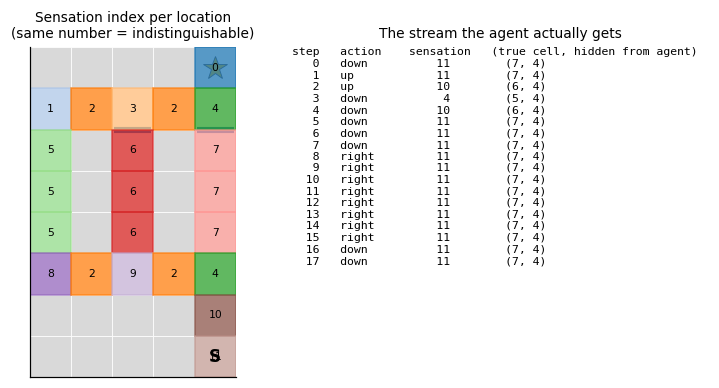

22 locations -> only 12 distinct sensations; 5 sensations are ambiguous.
A first-order model over sensations therefore cannot represent this maze at all.


In [ ]:
#@title The agent's-eye view: what the sensation stream actually looks like
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.6))

# left: which cells emit the same sensation
plots.draw_maze(axes[0], maze_both)
cmap = plt.get_cmap("tab20")
for s, (r, c) in enumerate(maze_both.cells):
    axes[0].add_patch(plt.Rectangle((c - .5, r - .5), 1, 1,
                                    color=cmap(maze_both.obs[s] % 20), alpha=.75, zorder=2))
    axes[0].text(c, r, str(maze_both.obs[s]), ha="center", va="center",
                 fontsize=7, zorder=3)
axes[0].set_title("Sensation index per location\n(same number = indistinguishable)", fontsize=9)

# right: a slice of the raw stream the agent receives
x_demo, a_demo, st_demo = maze_both.biased_walk(40, seed=3)
axes[1].axis("off")
lines = ["step   action    sensation   (true cell, hidden from agent)"]
for t in range(18):
    lines.append(f"{t:>4}   {ACTION_NAMES[a_demo[t]]:<8}  {x_demo[t]:>6}"
                 f"        {maze_both.cells[st_demo[t]]}")
axes[1].text(0, 1, "\n".join(lines), family="monospace", fontsize=7.5,
             va="top", transform=axes[1].transAxes)
axes[1].set_title("The stream the agent actually gets", fontsize=9)
plt.tight_layout(); plt.show()

n_amb = (np.bincount(maze_both.obs) > 1).sum()
print(f"{maze_both.n_states} locations -> only {maze_both.n_obs} distinct sensations; "
      f"{n_amb} sensations are ambiguous.")
print("A first-order model over sensations therefore cannot represent this maze at all.")

---

# Part 2 · Learning the cognitive map with a CSCG

A **clone-structured causal graph** is an action-augmented cloned HMM. Each discrete sensation is assigned a block of latent states — its *clones* — and the emission is deterministic: a clone emits exactly one sensation. Learning optimises only the action-conditional transition tensor

$$T[a,i,j] \;=\; P(z_{n+1}=j \mid z_n=i,\; a_n=a)$$

by EM. Given excess capacity, EM discovers how to **split** one sensation into several clones (when it occurs in different sequential contexts) and **merge** contexts that behave alike. Viterbi-EM then consolidates the superposition of graphs that soft EM leaves behind into a single sparse graph.

---

### One design decision worth stating plainly

We train the CSCG during **free exploration with the barriers open**. The learned map therefore already contains the shortcut edges, and a barrier becomes simply *a known edge whose current passability is uncertain*. This is not a convenience: it is Antonov & Dayan's own account of where uncertainty comes from — "forgetting, changes in the environment, or simply a lack of experience". It also avoids smuggling in the barrier's destination by hand, which would have been cheating.

In [ ]:
#@title Train the CSCG on aliased sensations
x_tr, a_tr, st_tr = maze_open.biased_walk(CFG["walk_steps"], seed=1, p_repeat=0.6)
print(f"training stream: {len(x_tr)} steps, "
      f"covering {len(np.unique(st_tr))}/{maze_open.n_states} locations")

t0 = time.time()
model, bits = cscg.train_cscg(
    x_tr, a_tr, maze_open.n_obs,
    clones_per_obs=CFG["clones_per_obs"], ep_len=200,
    em_iter=CFG["em_iter"], vit_iter=CFG["vit_iter"],
    n_restarts=CFG["n_restarts"], seed=3, verbose=False)
print(f"trained in {time.time()-t0:.0f}s   final bits/step = {bits:.4f}")

training stream: 15000 steps, covering 22/22 locations
trained in 257s   final bits/step = 0.0004


In [ ]:
#@title Did it recover the maze? (experimenter-side check)
used, remap, clone_cell, counts, fields = bridge.clone_cell_map(
    model, x_tr, a_tr, st_tr, maze_open)
succ_k = model.extract_graph(x_tr, a_tr)[1]

purity = (counts.max(axis=1) / counts.sum(axis=1)).mean()
ok = tot = 0
for k in range(len(used)):
    for act in range(4):
        j = succ_k[act, k]
        if j < 0: continue
        tot += 1
        ok += (clone_cell[j] == maze_open.succ[act, clone_cell[k]])

print(f"  clones used                 : {len(used)}  (for {maze_open.n_states} locations)")
print(f"  clone purity                : {purity:.4f}   (1.0 = every clone means one location)")
print(f"  transition-graph fidelity   : {ok}/{tot} = {ok/tot:.4f}")
print()
print("Note this check uses ground-truth positions the agent never sees.")
print("It is the experimenter's audit, not part of the model.")

  clones used                 : 30  (for 22 locations)
  clone purity                : 1.0000   (1.0 = every clone means one location)
  transition-graph fidelity   : 120/120 = 1.0000

Note this check uses ground-truth positions the agent never sees.
It is the experimenter's audit, not part of the model.


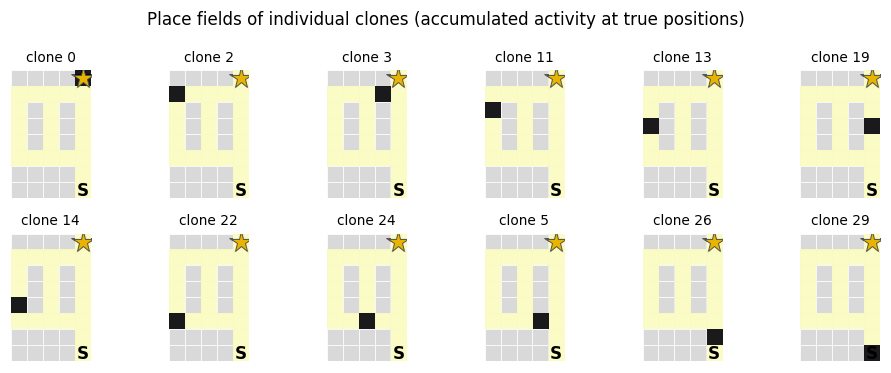

Each clone responds to the sequential context leading to a location, not to
the location itself. The agent has no mechanism to compute these maps, and
never needs to: it acts on clones directly.


In [ ]:
#@title Place fields are a plotting convention, not a computation
order = np.argsort([clone_cell[k] for k in range(len(used))])
sel = order[np.linspace(0, len(order) - 1, 12).astype(int)]
fig = plots.show_place_fields(fields, maze_open, sel, ncols=6,
        title="Place fields of individual clones (accumulated activity at true positions)")
plt.show()

print("Each clone responds to the sequential context leading to a location, not to")
print("the location itself. The agent has no mechanism to compute these maps, and")
print("never needs to: it acts on clones directly.")

In [ ]:
#@title CSCG's own replay: message-passing planning over the latent graph
start_clone = int(np.argmax(counts[:, maze_open.start_state]))
goal_clone  = int(np.argmax(counts[:, maze_open.goal_state]))
path, acts = model.bridge(used[start_clone], used[goal_clone], max_steps=25)

if path is not None:
    cell_of = {c: k for k, c in enumerate(used)}
    cells = [maze_open.cells[clone_cell[cell_of[c]]] for c in path]
    print("Inferred plan from start to goal (forward/backward max-product sweeps):")
    print("  clones :", list(path))
    print("  cells  :", cells)
    print("  actions:", [ACTION_NAMES[a] for a in acts])
    print(f"\n  length {len(acts)} steps -- optimal is {shortest(maze_open)}")
else:
    print("no bridge found")
print("\nThis is planning without coordinates: the route is read off the latent")
print("graph by message passing, exactly the sweeps the CSCG paper likens to replay.")

Inferred plan from start to goal (forward/backward max-product sweeps):
  clones : [np.int64(138), np.int64(1)]
  cells  : [(7, 4), (0, 4)]
  actions: ['up']

  length 1 steps -- optimal is 7

This is planning without coordinates: the route is read off the latent
graph by message passing, exactly the sweeps the CSCG paper likens to replay.


---

# Part 3 · Exploratory replay in Bayesian bandits (A&D Figs. 1–2)

Before the maze, Antonov & Dayan develop the theory in the simplest possible sequential decision problem. Two arms: $a_2$ has a **known** payoff $\mu_2$; $a_1$ has an unknown $\mu_1$ with a Beta belief. The belief state is $b=\{p(\mu_1),\mu_2\}$, and the planning tree branches on the *imagined* outcomes of exploratory pulls.

Two quantities prioritise replay:

* **exploratory Gain** — the local policy improvement at $b_k$ from the backup. Computed *in belief space*, it carries the value of information obtainable up to $b_k$.
* **exploratory Need** — how likely the agent is ever to reach $b_k$. Because the tree is not recurrent, Need is a reachability measure, not an occupancy count.

$$\mathrm{EVB}_{\pi_{\text{old}}}(b_k,a_k) = \mathrm{Need}\times\mathrm{Gain}$$

Updates run greedily until the best remaining EVB drops below a threshold $\xi$ — the opportunity cost that stops the agent being permanently buried in thought.

The set-up is deliberately adversarial to exploration: the known arm has the **higher** expected payoff ($\mu_2 = 0.51$ vs $\mathbb{E}[\mu_1] = 0.50$). A certainty-equivalent planner can only ever exploit.

In [ ]:
import mab
importlib.reload(mab)

tree = mab.BeliefTree(horizon=3, alpha=1.0, beta=1.0, mu2=0.51, gamma=0.9)
root = tree.index[(0, 0, 0)]
Qbo, v_bo = tree.bayes_optimal()
v_ce = tree.certainty_equivalent_optimum()

print(f"belief tree: {tree.n_nodes} nodes, horizon {tree.H}")
print(f"  Bayes-optimal value of the prior belief state : {v_bo:.4f}")
print(f"  certainty-equivalent optimum (Mattar & Daw)   : {v_ce:.4f}")
print(f"  value of information the CE planner misses    : {v_bo - v_ce:.4f}")

res = mab.prioritised_replay(tree, beta=2.0, xi=1e-4, init="ce", verbose=True)
q_root = res["Q"][root]
print()
print(f"  final root Q: explore={q_root[0]:.4f}  exploit={q_root[1]:.4f}"
      f"  -> agent chooses {'EXPLORE' if q_root[0] > q_root[1] else 'EXPLOIT'}")

belief tree: 20 nodes, horizon 3
  Bayes-optimal value of the prior belief state : 5.8618
  certainty-equivalent optimum (Mattar & Daw)   : 5.1000
  value of information the CE planner misses    : 0.7618
  replay 1: node(d=0,s=0,f=0) action=explore  EVB=0.2124
  replay 2: node(d=1,s=0,f=0) action=explore  EVB=0.0381
  replay 3: node(d=2,s=1,f=1) action=explore  EVB=0.0082
  replay 4: node(d=1,s=1,f=0) action=explore  EVB=0.0077
  replay 5: node(d=0,s=0,f=0) action=explore  EVB=0.0156
  replay 6: node(d=2,s=0,f=0) action=explore  EVB=0.0061
  replay 7: node(d=2,s=1,f=0) action=explore  EVB=0.0005
  replay 8: node(d=1,s=0,f=0) action=explore  EVB=0.0005

  final root Q: explore=5.8618  exploit=5.1000  -> agent chooses EXPLORE


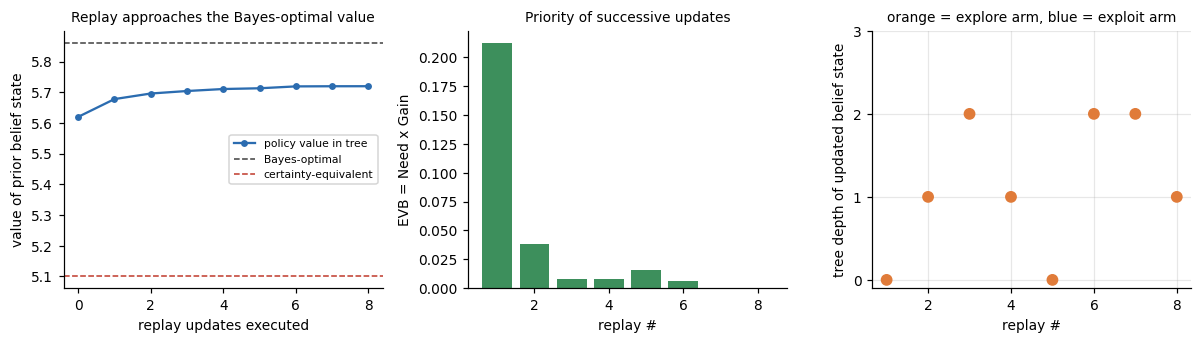

Later updates propagate the value of the *unknown* arm back towards the root.
The agent ends up preferring the arm with the LOWER expected immediate payoff,
because replay has priced in what it could learn -- and how it could then exploit it.


In [ ]:
#@title Fig. 1-2: replay propagates the value of what can be learned
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

ax = axes[0]
ax.plot(res["policy_values"], "-o", ms=3.5, color="#2b6cb0", label="policy value in tree")
ax.axhline(v_bo, ls="--", color="0.25", lw=1, label="Bayes-optimal")
ax.axhline(v_ce, ls="--", color="#c0392b", lw=1, label="certainty-equivalent")
ax.set_xlabel("replay updates executed"); ax.set_ylabel("value of prior belief state")
ax.set_title("Replay approaches the Bayes-optimal value"); ax.legend(fontsize=7)

ax = axes[1]
ax.bar(np.arange(1, len(res["evb"]) + 1), res["evb"], color="#3d8f5c")
ax.set_xlabel("replay #"); ax.set_ylabel("EVB = Need x Gain")
ax.set_title("Priority of successive updates")

ax = axes[2]
depths = [tree.nodes[i][0] for i, a in res["updates"]]
kinds  = ["explore" if a == 0 else "exploit" for i, a in res["updates"]]
colors = ["#e07b39" if k == "explore" else "#5b8cc7" for k in kinds]
ax.scatter(np.arange(1, len(depths) + 1), depths, c=colors, s=45, zorder=3)
ax.set_xlabel("replay #"); ax.set_ylabel("tree depth of updated belief state")
ax.set_yticks(range(tree.H + 1)); ax.set_title("orange = explore arm, blue = exploit arm")
ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("Later updates propagate the value of the *unknown* arm back towards the root.")
print("The agent ends up preferring the arm with the LOWER expected immediate payoff,")
print("because replay has priced in what it could learn -- and how it could then exploit it.")

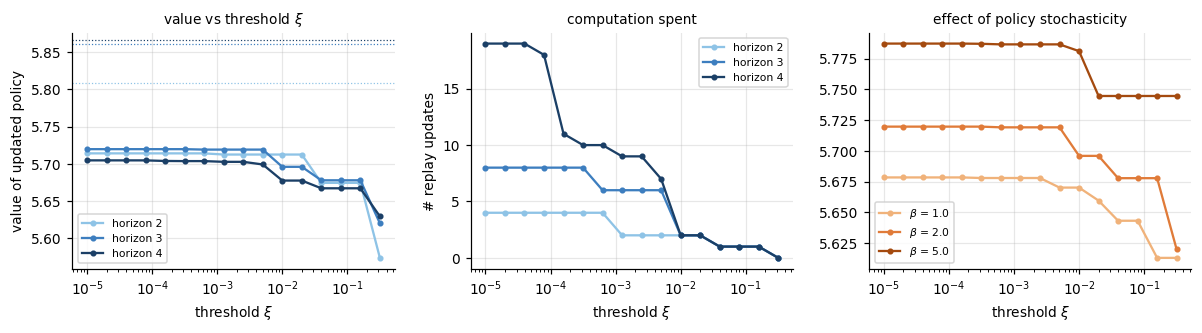

Dotted lines: the Bayes-optimal value for each horizon. A lower threshold buys
more replay and a better policy, with diminishing returns -- the trade-off xi encodes.


In [ ]:
#@title Fig. 2d-f: the effect of the stopping threshold, horizon and policy stochasticity
fig, axes = plt.subplots(1, 3, figsize=(11, 3.1), sharex=True)
xis = np.logspace(-5, -0.5, 16)

for H, col in zip([2, 3, 4], ["#8ec3e6", "#3d7ebf", "#1b3f66"]):
    tr = mab.BeliefTree(horizon=H, alpha=1, beta=1, mu2=0.51, gamma=0.9)
    _, vbo_h = tr.bayes_optimal()
    vals, npdt = [], []
    for xi in xis:
        r = mab.prioritised_replay(tr, beta=2.0, xi=xi, init="ce")
        vals.append(r["policy_values"][-1]); npdt.append(r["n_updates"])
    axes[0].semilogx(xis, vals, "-o", ms=3, color=col, label=f"horizon {H}")
    axes[0].axhline(vbo_h, ls=":", lw=.8, color=col)
    axes[1].semilogx(xis, npdt, "-o", ms=3, color=col, label=f"horizon {H}")

tr = mab.BeliefTree(horizon=3, alpha=1, beta=1, mu2=0.51, gamma=0.9)
for b, col in zip([1.0, 2.0, 5.0], ["#f0b27a", "#e07b39", "#a44a0f"]):
    vals = [mab.prioritised_replay(tr, beta=b, xi=xi, init="ce")["policy_values"][-1]
            for xi in xis]
    axes[2].semilogx(xis, vals, "-o", ms=3, color=col, label=f"$\\beta$ = {b}")

axes[0].set_ylabel("value of updated policy"); axes[0].set_title("value vs threshold $\\xi$")
axes[1].set_ylabel("# replay updates");        axes[1].set_title("computation spent")
axes[2].set_title("effect of policy stochasticity")
for ax in axes:
    ax.set_xlabel("threshold $\\xi$"); ax.legend(fontsize=7); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("Dotted lines: the Bayes-optimal value for each horizon. A lower threshold buys")
print("more replay and a better policy, with diminishing returns -- the trade-off xi encodes.")

In [ ]:
#@title Supplementary Fig. 4: sequence replay is biased towards reverse
seq = mab.sequence_replay(tree, beta=2.0, xi=1e-4, max_len=3, max_events=30)
single = mab.prioritised_replay(tree, beta=2.0, xi=1e-4, init="ce")

n_rev = sum(d == "reverse" for d in seq["directions"])
n_fwd = sum(d == "forward" for d in seq["directions"])
print(f"sequence replay events : {len(seq['events'])}  "
      f"({n_rev} reverse, {n_fwd} forward)")
print(f"total actions updated  : sequence={seq['n_actions_updated']}  "
      f"single-action={single['n_updates']}")
print()
print("Reverse dominates but forward sequences are a substantial minority -- as reported.")
print("Sequence replay also updates more actions, which follows from its open-loop nature.")

sequence replay events : 3  (2 reverse, 1 forward)
total actions updated  : sequence=7  single-action=8

Reverse dominates but forward sequences are a substantial minority -- as reported.
Sequence replay also updates more actions, which follows from its open-loop nature.


---

# Part 4 · One replay engine, two state spaces

Everything from here on runs on a `GraphMDP`: a deterministic successor table plus a set of *hypothetical* barrier edges whose passability $\mu \sim \mathrm{Beta}(\alpha,\beta)$ is unknown. It knows nothing about rows, columns, or distance. That is what lets us build it two ways and compare.

Model-free Q-values are indexed by **graph node alone**, so a replay update at a node benefits every belief state sharing it — the generalisation across belief space Antonov & Dayan discuss.

One honesty note on the clone graph: identifying *which* edges are barriers uses the experimenter's clone→cell map. Agent-side this corresponds to the clone that was active when it bumped, so nothing conceptual is being smuggled in — but the convenience is worth flagging.

In [ ]:
mdp_gt = bridge.mdp_from_maze(maze_both, uncertain=(0,), gamma=0.9)
mdp_cs = bridge.mdp_from_cscg(model, x_tr, a_tr, st_tr, maze_both,
                              uncertain=(0,), gamma=0.9)
MDPS = [("ground-truth", mdp_gt, maze_both), ("clone-graph", mdp_cs, maze_both)]

print(f"  ground-truth MDP : {mdp_gt.K} nodes (true maze cells)")
print(f"  clone-graph  MDP : {mdp_cs.K} nodes (CSCG clones)")
print()
for b in mdp_cs.barriers:
    print(f"  uncertain edge (clone space): {b['src']} --{ACTION_NAMES[b['action']]}--> {b['dst']}"
          f"   [cells {maze_both.cells[mdp_cs.clone_cell[b['src']]]}"
          f" -> {maze_both.cells[mdp_cs.clone_cell[b['dst']]]}]")

print()
for name, mdp, mz in MDPS:
    Q = replay.value_iteration(mdp)
    print(f"  {name:<13} V(start) = {Q[mdp.start].max():.4f}")
print("\nSame value from a 22-node coordinate map and a 30-node clone graph.")

  ground-truth MDP : 22 nodes (true maze cells)
  clone-graph  MDP : 30 nodes (CSCG clones)

  uncertain edge (clone space): 18 --up--> 9   [cells (2, 4) -> (1, 4)]

  ground-truth  V(start) = 0.2881
  clone-graph   V(start) = 0.2881

Same value from a 22-node coordinate map and a 30-node clone graph.


---

# Part 5 · Exploitative replay is suboptimal (A&D Fig. 3)

First, the failure mode that motivates the whole paper. Mattar & Daw's agent assumes its model is **exact**, so replay can only ever exploit what it already knows; it can never price the resolution of uncertainty.

* **Phase 1** — both barriers present. Only the longest corridor works. The agent learns it.
* **Phase 2** — the top barrier is silently **removed**, opening a much shorter route.

The prediction is that the agent keeps taking the long way round: its replay is "incapable of foreseeing the opening of the shortcut". We add forgetting (Q-values decay towards a fixed value) so that replay persists throughout, as in the paper.

In [ ]:
#@title Run both phases, for both state spaces
def run_fig3(mdp_blocked, mdp_open, steps, seed=0):
    ag = replay.MattarDawAgent(mdp_blocked, alpha=0.5, beta=8.0, xi=1e-4,
                               q_init=0.3, forget=0.005, max_replay=8, seed=seed)
    r1 = ag.run(steps)
    ag.mdp = mdp_open              # barrier silently removed
    r2 = ag.run(steps)
    return ag, r1, r2

mdp_gt_open = bridge.mdp_from_maze(maze_shortcut, uncertain=())
mdp_cs_open = bridge.mdp_from_cscg(model, x_tr, a_tr, st_tr, maze_shortcut,
                                   uncertain=())
mdp_gt_blk  = bridge.mdp_from_maze(maze_both, uncertain=())
mdp_cs_blk  = bridge.mdp_from_cscg(model, x_tr, a_tr, st_tr, maze_both,
                                   uncertain=())

t0 = time.time()
FIG3 = {}
FIG3["ground-truth"] = run_fig3(mdp_gt_blk, mdp_gt_open, CFG["fig3_steps"])
FIG3["clone-graph"]  = run_fig3(mdp_cs_blk, mdp_cs_open, CFG["fig3_steps"])
print(f"done in {time.time()-t0:.0f}s")

for name, (ag, r1, r2) in FIG3.items():
    print(f"\n{name}:")
    print(f"   phase 1 (barrier present) reward rate = {r1['reward_rate']:.4f}")
    print(f"   phase 2 (shortcut open)   reward rate = {r2['reward_rate']:.4f}")
    print(f"   optimal rate if shortcut were used    = {1/shortest(maze_shortcut):.4f}")

done in 75s

ground-truth:
   phase 1 (barrier present) reward rate = 0.0085
   phase 2 (shortcut open)   reward rate = 0.1365
   optimal rate if shortcut were used    = 0.1429

clone-graph:
   phase 1 (barrier present) reward rate = 0.0085
   phase 2 (shortcut open)   reward rate = 0.1375
   optimal rate if shortcut were used    = 0.1429


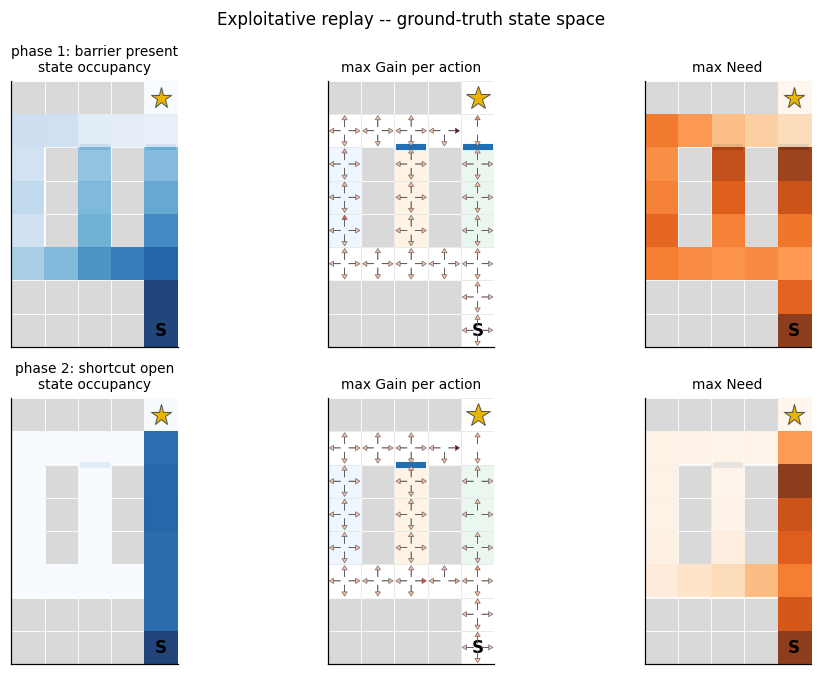

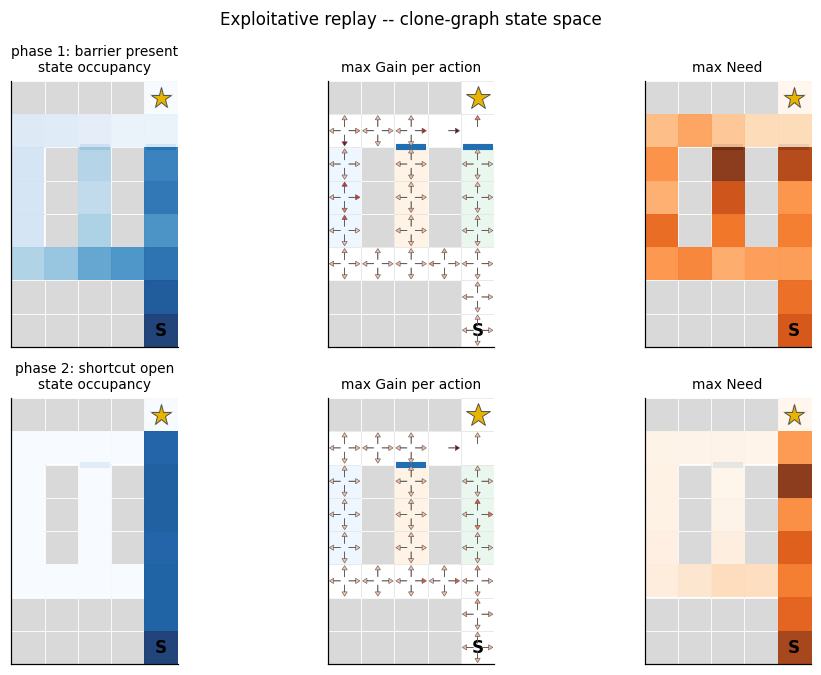

The occupancy maps tell the story: in phase 2 the agent's behaviour has
collapsed to pure exploitation of the long corridor. The shortcut is open and
it never finds out. Both state spaces reproduce this failure identically.


In [ ]:
#@title Fig. 3: occupancy, Gain and Need, before and after the barrier is removed
for name, (ag, r1, r2) in FIG3.items():
    mdp = ag.mdp
    fig, axes = plt.subplots(2, 3, figsize=(9.6, 6.2))
    for row, (res, mz, lab) in enumerate([(r1, maze_both, "phase 1: barrier present"),
                                          (r2, maze_shortcut, "phase 2: shortcut open")]):
        occ = bridge.project_to_grid(res["occupancy"], mdp, mz, mode="sum")
        plots.heat_on_maze(axes[row, 0], mz, occ, f"{lab}\nstate occupancy", cmap="Blues")
        need = bridge.project_to_grid(res["need"], mdp, mz, mode="max")
        plots.heat_on_maze(axes[row, 2], mz, need, "max Need", cmap="Oranges")
        plots.draw_maze(axes[row, 1], mz)
        g = bridge.project_actions_to_grid(res["gain"], mdp, mz)
        plots.action_arrows(axes[row, 1], mz, g, cmap="Reds")
        axes[row, 1].set_title("max Gain per action", fontsize=9)
    fig.suptitle(f"Exploitative replay -- {name} state space", fontsize=11)
    plt.tight_layout(); plt.show()

print("The occupancy maps tell the story: in phase 2 the agent's behaviour has")
print("collapsed to pure exploitation of the long corridor. The shortcut is open and")
print("it never finds out. Both state spaces reproduce this failure identically.")

---

# Part 6 · Exploratory replay in belief space (A&D Figs. 4–5)

Now the fix. Augment the state with a belief about the barrier: $b=\{s,p(\mu)\}$. The exploitative action ("down") changes only the physical component. The exploratory action ("up") splits the future in two: the agent either crosses, learning the barrier is absent and changing location, or fails, changing only its belief.

The agent's model-free policy is initialised to one compatible with all but the longest path being blocked — it already knows the long way round. Its prior belief about the top barrier says, with some uncertainty, that it might be open.

> **Prediction:** consecutive replay updates originating at the barrier and progressing in reverse towards the agent, propagating the value of exploring — followed by directed exploration of that arm.

In [ ]:
#@title Exploratory replay from the start state
EXPL = {}
for name, mdp, mz in MDPS:
    Q_prior = replay.value_iteration(mdp)          # knows only the long route
    Q_post, events, tree = replay.exploratory_replay(
        mdp, Q_prior, root_state=mdp.start, horizon=CFG["horizon"],
        beta=5.0, xi=1e-6, max_updates=12)
    EXPL[name] = (mdp, mz, Q_prior, Q_post, events)

    cell = lambda s: mz.cells[mdp.clone_cell[s]] if hasattr(mdp, "clone_cell") else mz.cells[s]
    print(f"\n{name}:  {len(events)} replay updates")
    for e in events[:8]:
        print(f"   {e['order']:>2}. {str(cell(e['state'])):<8} {ACTION_NAMES[e['action']]:<6}"
              f" EVB={e['evb']:.5f}  Gain={e['gain']:.5f}  Need={e['need']:.4f}")
    print("   post-replay greedy route:",
          [cell(s) for s in replay.greedy_policy_path(mdp, Q_post)][:8])


ground-truth:  12 replay updates
    1. (2, 4)   up     EVB=0.01446  Gain=0.22461  Need=0.0644
    2. (3, 4)   up     EVB=0.01668  Gain=0.15003  Need=0.1112
    3. (4, 4)   up     EVB=0.02256  Gain=0.08333  Need=0.2708
    4. (2, 4)   up     EVB=0.03457  Gain=0.08560  Need=0.4039
    5. (5, 4)   up     EVB=0.02840  Gain=0.03907  Need=0.7268
    6. (6, 4)   up     EVB=0.04356  Gain=0.02482  Need=1.7550
    7. (7, 4)   up     EVB=0.06339  Gain=0.01857  Need=3.4129
    8. (3, 4)   up     EVB=0.02881  Gain=0.08448  Need=0.3411
   post-replay greedy route: [(7, 4), (6, 4), (5, 4), (4, 4), (3, 4), (2, 4)]

clone-graph:  12 replay updates
    1. (2, 4)   up     EVB=0.01446  Gain=0.22461  Need=0.0644
    2. (3, 4)   up     EVB=0.01194  Gain=0.15003  Need=0.0796
    3. (4, 4)   up     EVB=0.02337  Gain=0.08333  Need=0.2805
    4. (2, 4)   up     EVB=0.03080  Gain=0.08560  Need=0.3598
    5. (5, 4)   up     EVB=0.02849  Gain=0.03907  Need=0.7291
    6. (6, 4)   up     EVB=0.04146  Gain=0.02482 

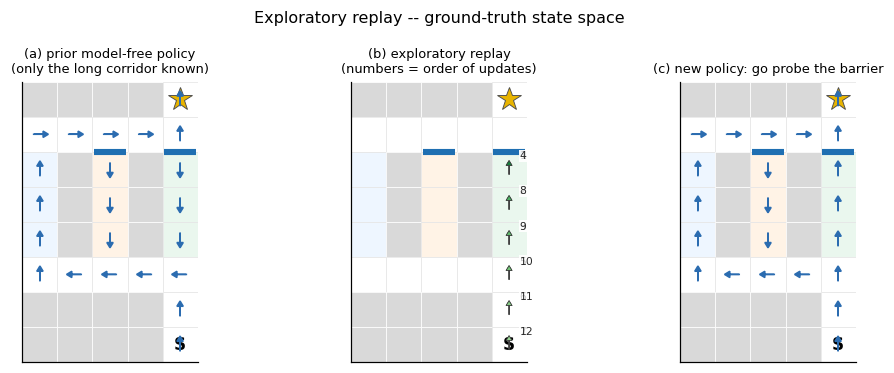

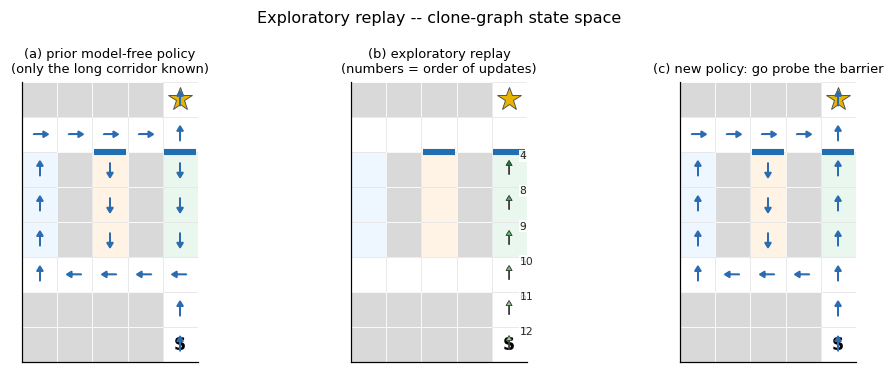

Replay starts at the barrier and marches in reverse down the central corridor
to the agent, carrying the exploratory bonus with it. The resulting policy
abandons the safe long route in favour of probing the shortcut.

This is a concrete experimental prediction: reverse place-cell sequences
along the arm, followed by directed exploration of it.


In [ ]:
#@title Fig. 5a-c: prior policy -> replay -> exploratory policy
for name, (mdp, mz, Q_prior, Q_post, events) in EXPL.items():
    fig, axes = plt.subplots(1, 3, figsize=(9.6, 3.4))
    plots.draw_maze(axes[0], mz); plots.policy_arrows(axes[0], mz, Q_prior, mdp)
    axes[0].set_title("(a) prior model-free policy\n(only the long corridor known)", fontsize=8.5)

    plots.draw_maze(axes[1], mz)
    plots.replay_sequence(axes[1], mz, events, mdp)
    axes[1].set_title("(b) exploratory replay\n(numbers = order of updates)", fontsize=8.5)

    plots.draw_maze(axes[2], mz); plots.policy_arrows(axes[2], mz, Q_post, mdp)
    axes[2].set_title("(c) new policy: go probe the barrier", fontsize=8.5)
    fig.suptitle(f"Exploratory replay -- {name} state space", fontsize=10.5)
    plt.tight_layout(); plt.show()

print("Replay starts at the barrier and marches in reverse down the central corridor")
print("to the agent, carrying the exploratory bonus with it. The resulting policy")
print("abandons the safe long route in favour of probing the shortcut.")
print()
print("This is a concrete experimental prediction: reverse place-cell sequences")
print("along the arm, followed by directed exploration of it.")

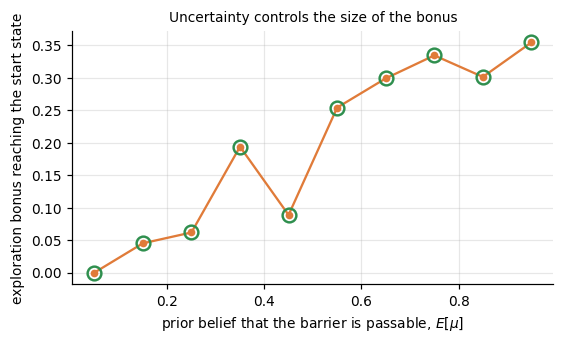

Green rings: the agent actually switches to exploring. The extent of the
agent's uncertainty determines the size of the bonus that reaches its
current state -- a directly testable, parametric prediction.


In [ ]:
#@title How much uncertainty is needed? (parametric prediction)
fig, ax = plt.subplots(figsize=(5.2, 3.2))
mdp, mz = mdp_gt, maze_both
probes = np.linspace(0.05, 0.95, 10)
bonus, switch = [], []
for p in probes:
    m2 = bridge.mdp_from_maze(mz, uncertain=(0,), alpha=8 * p, beta=8 * (1 - p))
    Qp = replay.value_iteration(m2)
    Qn, ev, _ = replay.exploratory_replay(m2, Qp, m2.start, horizon=CFG["horizon"],
                                          beta=5.0, xi=1e-6, max_updates=12)
    bonus.append(Qn[m2.start, UP] - Qp[m2.start, UP])
    switch.append(int(np.argmax(Qn[m2.start])) == UP)

ax.plot(probes, bonus, "-o", ms=4, color="#e07b39")
ax.set_xlabel("prior belief that the barrier is passable, $E[\\mu]$")
ax.set_ylabel("exploration bonus reaching the start state")
ax.set_title("Uncertainty controls the size of the bonus")
for p, s, b in zip(probes, switch, bonus):
    if s: ax.plot(p, b, "o", ms=9, mfc="none", mec="#2f8f4e", mew=1.6)
ax.grid(alpha=.3); plt.tight_layout(); plt.show()
print("Green rings: the agent actually switches to exploring. The extent of the")
print("agent's uncertainty determines the size of the bonus that reaches its")
print("current state -- a directly testable, parametric prediction.")

---

# Part 7 · Sequence replay and deep propagation (A&D Fig. 6)

Resolving uncertainty can end badly. Suppose the agent probes the barrier and finds it **present**. Now it must undo the whole exploratory policy that led it there — including the intermediate states that were optimistically inflated by the now-obsolete bonus.

Single-action updates are **myopic**: the benefit of one backup does not account for how it changes the benefit of later ones. The paper's claim is that they fail here. The proposed fix is to evaluate whole **sequences** of updates, whose benefit is a *single far-sighted quantity* rather than a sum of local ones.

---

### An implementation subtlety worth stating

The expected value of a backup is $V_{\pi_{\text{new}}}(b) - V_{\pi_{\text{old}}}(b)$ with **both terms evaluated under the updated Q-values** (their Eq. 7). If you instead compare new-policy-under-new-Q against old-policy-under-old-Q, any replay that *lowers* an over-optimistic estimate scores negatively and is never selected — and the agent becomes constitutionally incapable of learning from bad news. Getting this right is what makes the correction below work at all.

In [ ]:
#@title The agent probes the barrier and finds it present
SEQ = {}
for name, mdp, mz in MDPS:
    _, _, Q_prior, Q_expl, _ = EXPL[name]
    src = mdp.barriers[0]["src"]
    # six failed attempts.  The clone graph may carry several barrier edges for
    # the same physical barrier (one per clone of that location), so the counts
    # tuple has to match the number of edges, not be hard-coded to one.
    post = tuple((0, 6) for _ in mdp.barriers)
    Q_disc = Q_expl.copy(); Q_disc[src, UP] = 0.0    # online: bumped, no reward

    Q_single, ev_s, _ = replay.exploratory_replay(
        mdp, Q_disc, src, root_counts=post, horizon=CFG["horizon"] + 1,
        beta=5.0, xi=1e-8, max_updates=30)
    Q_seq, ev_q, _ = replay.sequence_replay(
        mdp, Q_disc, src, root_counts=post, horizon=CFG["horizon"] + 1,
        beta=5.0, xi=1e-8, max_events=CFG["seq_events"], max_len=8)
    SEQ[name] = (mdp, mz, Q_expl, Q_single, Q_seq, ev_s, ev_q, post)
    print(f"{name}: p(passable) after discovery = {mdp.p_passable(0, post):.3f};"
          f"  {len(ev_s)} single updates, {len(ev_q)} sequence events")

ground-truth: p(passable) after discovery = 0.125;  30 single updates, 8 sequence events
clone-graph: p(passable) after discovery = 0.125;  30 single updates, 8 sequence events


cell       truth  inflated   single  sequence
(5, 4)     0.288     0.637    0.859     0.574
(4, 4)     0.259     0.708    0.955     0.637
(3, 4)     0.233     0.787    1.061     0.629
(2, 4)     0.233     0.874    1.239     0.699

mean |error| vs truth along the corridor:
   before any correction : 0.4981
   single-action replay  : 0.7752   <- WORSE than doing nothing
   sequence replay       : 0.3812


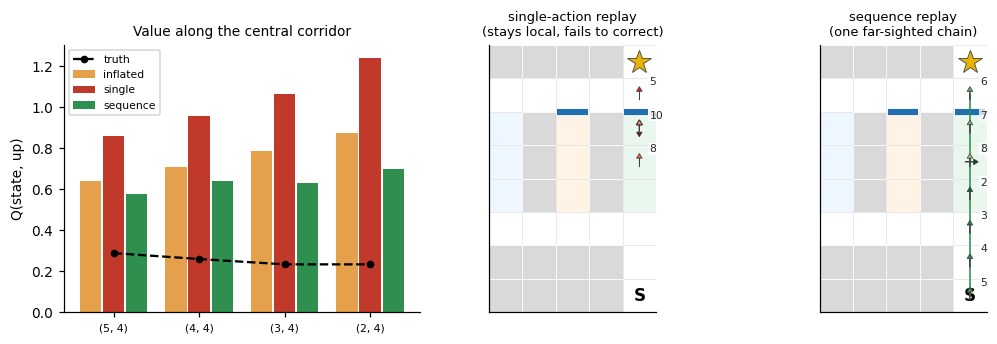

In [ ]:
#@title Fig. 6: does the bad news reach the start state?
name = "ground-truth"
mdp, mz, Q_expl, Q_single, Q_seq, ev_s, ev_q, post = SEQ[name]
Q_true = replay.value_iteration(mdp)      # ground truth: barrier known present
corridor = [(5, 4), (4, 4), (3, 4), (2, 4)]
rows = []
for c in corridor:
    s = mz.cell_index[c]
    rows.append((str(c), Q_true[s, UP], Q_expl[s, UP], Q_single[s, UP], Q_seq[s, UP]))

print(f"{'cell':<8}{'truth':>8}{'inflated':>10}{'single':>9}{'sequence':>10}")
for r in rows:
    print(f"{r[0]:<8}{r[1]:>8.3f}{r[2]:>10.3f}{r[3]:>9.3f}{r[4]:>10.3f}")

idx = [mz.cell_index[c] for c in corridor]
e_inf = np.abs(Q_expl[idx, UP] - Q_true[idx, UP]).mean()
e_sng = np.abs(Q_single[idx, UP] - Q_true[idx, UP]).mean()
e_seq = np.abs(Q_seq[idx, UP] - Q_true[idx, UP]).mean()
print(f"\nmean |error| vs truth along the corridor:")
print(f"   before any correction : {e_inf:.4f}")
print(f"   single-action replay  : {e_sng:.4f}   <- WORSE than doing nothing")
print(f"   sequence replay       : {e_seq:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
lbl = [r[0] for r in rows]; xs = np.arange(len(lbl))
axes[0].bar(xs - .27, [r[2] for r in rows], .25, label="inflated", color="#e5a04c")
axes[0].bar(xs,        [r[3] for r in rows], .25, label="single",   color="#c0392b")
axes[0].bar(xs + .27,  [r[4] for r in rows], .25, label="sequence", color="#2f8f4e")
axes[0].plot(xs, [r[1] for r in rows], "k--o", ms=4, label="truth")
axes[0].set_xticks(xs); axes[0].set_xticklabels(lbl, fontsize=7)
axes[0].set_ylabel("Q(state, up)"); axes[0].legend(fontsize=7)
axes[0].set_title("Value along the central corridor")

plots.draw_maze(axes[1], mz); plots.replay_sequence(axes[1], mz, ev_s[:10], mdp, cmap="Reds")
axes[1].set_title("single-action replay\n(stays local, fails to correct)", fontsize=8.5)

plots.draw_maze(axes[2], mz)
if ev_q:
    plots.replay_sequence(axes[2], mz, ev_q[0]["chain"], mdp, cmap="Greens", chain=True)
axes[2].set_title("sequence replay\n(one far-sighted chain)", fontsize=8.5)
plt.tight_layout(); plt.show()

In [ ]:
#@title Same contrast on the clone graph
name = "clone-graph"
mdp, mz, Q_expl, Q_single, Q_seq, ev_s, ev_q, post = SEQ[name]
Q_true = replay.value_iteration(mdp)
idx = [k for k in range(mdp.K) if mz.cells[mdp.clone_cell[k]] in corridor]
print(f"mean |error| vs truth over the corridor clones ({len(idx)} clones):")
print(f"   before any correction : {np.abs(Q_expl[idx, UP]  - Q_true[idx, UP]).mean():.4f}")
print(f"   single-action replay  : {np.abs(Q_single[idx, UP]- Q_true[idx, UP]).mean():.4f}")
print(f"   sequence replay       : {np.abs(Q_seq[idx, UP]   - Q_true[idx, UP]).mean():.4f}")
print()
print("The clone graph reproduces the ordering: single-action replay leaves values")
print("inflated, sequence replay pulls them back down. Latent sequential states are")
print("a sufficient substrate for non-myopic replay.")

mean |error| vs truth over the corridor clones (5 clones):
   before any correction : 0.3985
   single-action replay  : 0.8004
   sequence replay       : 0.2343

The clone graph reproduces the ordering: single-action replay leaves values
inflated, sequence replay pulls them back down. Latent sequential states are
a sufficient substrate for non-myopic replay.


---

# Part 8 · Replay in a blocked corridor, and Ólafsdóttir et al. (A&D Fig. 7)

Hippocampal replay has been observed to construct sequences through **space the animal has never traversed** (Ólafsdóttir et al. 2015). On Antonov & Dayan's account this is replay at *future belief states* the agent has not visited but can imagine reaching.

We reproduce both halves:

1. **Blocked corridor** — the central corridor is occluded at both ends, so the agent has never entered it. Replay nonetheless runs *inside* it, valuing the possibility of entering (resolving the bottom barrier), exiting (the top barrier), and arriving near the goal.
2. **Ólafsdóttir T-maze** — rats ran a central stem with a see-through barrier blocking the side arms. *Rest 1* (before any experience of the arms) showed no detectable replay of either arm. After a reward was made visible in one arm — but before the barrier was removed — *Rest 2* showed the **cued** arm replayed above chance and the uncued arm not.

barriers: [((2, 4), 'up', (1, 4)), ((5, 4), 'up', (4, 4))]

14 replay updates, 6 of them INSIDE the never-visited corridor


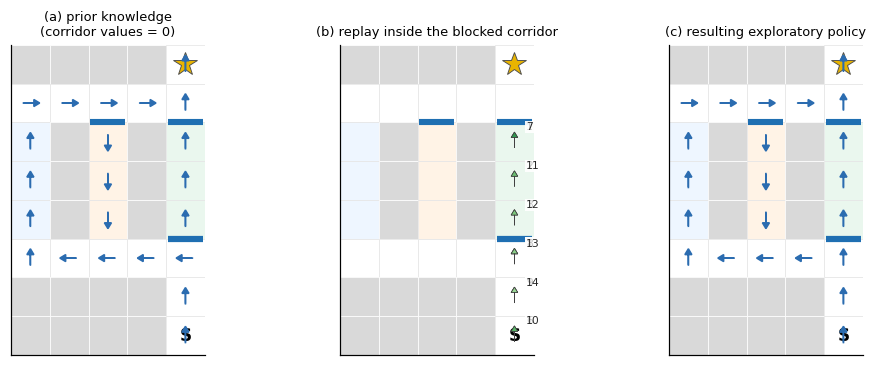

These updates are made at belief states DIFFERENT from the agent's current one
(reaching them requires first learning the bottom barrier is passable).
So this replay would likely not be decodable using the animal's current belief
state -- even though it is squarely in the service of the task. We quantify
that claim in Part 9.


In [ ]:
#@title 8a. Replay inside a corridor the agent has never entered
maze_bc = mazes.make_blocked_corridor()
mdp_bc = bridge.mdp_from_maze(maze_bc, uncertain=(0, 2))   # both ends uncertain
print("barriers:", [(maze_bc.cells[b['src']], ACTION_NAMES[b['action']],
                     maze_bc.cells[b['dst']]) for b in mdp_bc.barriers])

Q_bc = replay.value_iteration(mdp_bc)
Q_bc[[maze_bc.cell_index[c] for c in [(4, 4), (3, 4)]], :] = 0.0   # never experienced
Q_bc2, ev_bc, tree_bc = replay.exploratory_replay(
    mdp_bc, Q_bc, mdp_bc.start, horizon=CFG["horizon"] + 2,
    beta=5.0, xi=1e-7, max_updates=14)

inside = [(4, 4), (3, 4), (2, 4)]
n_in = sum(maze_bc.cells[e["state"]] in inside for e in ev_bc)
print(f"\n{len(ev_bc)} replay updates, {n_in} of them INSIDE the never-visited corridor")

fig, axes = plt.subplots(1, 3, figsize=(9.6, 3.4))
plots.draw_maze(axes[0], maze_bc); plots.policy_arrows(axes[0], maze_bc, Q_bc, mdp_bc)
axes[0].set_title("(a) prior knowledge\n(corridor values = 0)", fontsize=8.5)
plots.draw_maze(axes[1], maze_bc); plots.replay_sequence(axes[1], maze_bc, ev_bc, mdp_bc)
axes[1].set_title("(b) replay inside the blocked corridor", fontsize=8.5)
plots.draw_maze(axes[2], maze_bc); plots.policy_arrows(axes[2], maze_bc, Q_bc2, mdp_bc)
axes[2].set_title("(c) resulting exploratory policy", fontsize=8.5)
plt.tight_layout(); plt.show()

print("These updates are made at belief states DIFFERENT from the agent's current one")
print("(reaching them requires first learning the bottom barrier is passable).")
print("So this replay would likely not be decodable using the animal's current belief")
print("state -- even though it is squarely in the service of the task. We quantify")
print("that claim in Part 9.")

T-maze ('L'/'R' arm cues, see-through barrier at the top of the stem):
   LLL.RRR
   ###.###
   ###.###
   ###S###


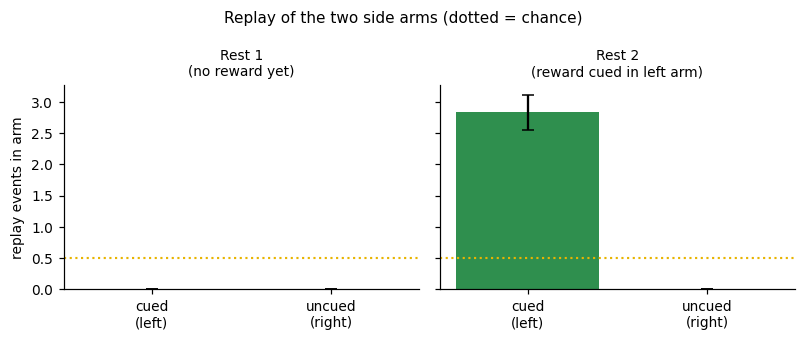

Rest 1 (no reward)   : left 0.00, right 0.00   -> no detectable replay of either arm
Rest 2 (left cued)   : left 2.83, right 0.00   -> the cued arm replayed, the uncued arm not
Rest 2 (right cued)  : left 0.00, right 2.83   -> mirror image, so this is not a left/right asymmetry of the maze

The model reproduces the pattern, and supplies a normative reading of it:
the animal is computing, during rest, an exploratory policy for probing the
barrier on the next run -- and only the arm with something worth reaching
is worth the computation.


In [ ]:
#@title 8b. Olafsdottir et al. (2015): cued vs uncued arm
tmaze = mazes.make_tmaze()
print("T-maze ('L'/'R' arm cues, see-through barrier at the top of the stem):")
for row in tmaze.grid: print("   " + "".join(row))

LEFT_ARM  = [(0, 0), (0, 1), (0, 2)]
RIGHT_ARM = [(0, 4), (0, 5), (0, 6)]
LEFT_GOAL, RIGHT_GOAL = (0, 0), (0, 6)     # far end of each arm, kept symmetric

def arm_replay_counts(cued_goal, n_seeds=12):
    # replay updates falling in each arm, across a range of prior beliefs
    counts = {"left": [], "right": []}
    for k in range(n_seeds):
        p = 0.15 + 0.7 * k / max(n_seeds - 1, 1)
        tm = mazes.make_tmaze()
        if cued_goal is not None:
            tm.goal = cued_goal
            tm.goal_state = tm.cell_index[cued_goal]
        else:
            tm.goal, tm.goal_state = None, -1
        m = bridge.mdp_from_maze(tm, uncertain=(0,), alpha=6 * p, beta=6 * (1 - p))
        if cued_goal is None:
            m.reward = 0.0
        Qp = replay.value_iteration(m)
        Qn, ev, _ = replay.exploratory_replay(m, Qp, m.start, horizon=6,
                                              beta=5.0, xi=1e-7, max_updates=14)
        cl = lambda s: tm.cells[s]
        counts["left"].append(sum(cl(e["state"]) in LEFT_ARM for e in ev))
        counts["right"].append(sum(cl(e["state"]) in RIGHT_ARM for e in ev))
    return counts

rest1 = arm_replay_counts(None)        # no reward anywhere
rest2 = arm_replay_counts(LEFT_GOAL)   # reward visible at the end of the LEFT arm
rest2r = arm_replay_counts(RIGHT_GOAL) # control: cue the RIGHT arm instead

fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.1), sharey=True)
for ax, (cts, lab) in zip(axes, [(rest1, "Rest 1\n(no reward yet)"),
                                 (rest2, "Rest 2\n(reward cued in left arm)")]):
    means = [np.mean(cts["left"]), np.mean(cts["right"])]
    sems  = [np.std(cts["left"]) / np.sqrt(len(cts["left"])),
             np.std(cts["right"]) / np.sqrt(len(cts["right"]))]
    ax.bar(["cued\n(left)", "uncued\n(right)"], means, yerr=sems, capsize=4,
           color=["#2f8f4e", "#9aa5b1"])
    ax.axhline(0.5, ls=":", color="#e8b400", lw=1.4)
    ax.set_title(lab, fontsize=9)
axes[0].set_ylabel("replay events in arm")
fig.suptitle("Replay of the two side arms (dotted = chance)", fontsize=10)
plt.tight_layout(); plt.show()

print(f"Rest 1 (no reward)   : left {np.mean(rest1['left']):.2f}, right {np.mean(rest1['right']):.2f}"
      "   -> no detectable replay of either arm")
print(f"Rest 2 (left cued)   : left {np.mean(rest2['left']):.2f}, right {np.mean(rest2['right']):.2f}"
      "   -> the cued arm replayed, the uncued arm not")
print(f"Rest 2 (right cued)  : left {np.mean(rest2r['left']):.2f}, right {np.mean(rest2r['right']):.2f}"
      "   -> mirror image, so this is not a left/right asymmetry of the maze")
print()
print("The model reproduces the pattern, and supplies a normative reading of it:")
print("the animal is computing, during rest, an exploratory policy for probing the")
print("barrier on the next run -- and only the arm with something worth reaching")
print("is worth the computation.")

---

# Part 9 · Predictions unique to the combined theory

Everything so far shows the clone graph *reproduces* Antonov & Dayan. The interesting question is what the combination predicts that neither paper does alone. Three things.

---

### 9a. Replay quality degrades with latent capacity, not with sensory richness

CSCG's account of place-field expansion and repetition is that the model cannot split long undifferentiated sequential contexts into distinct clones. If replay runs on clones, then **under-capacity should corrupt replay in a specific way**: the agent confuses positions within uniform corridors, and the reverse sequence from the barrier breaks up.

Note the control: we hold the *sensations* fixed and vary only latent capacity.

In [ ]:
#@title Sweep the CSCG's clone capacity
# Reference: the replay sequence produced on the ground-truth state space.
gt_events = EXPL["ground-truth"][4]
gt_seq = {(maze_both.cells[e["state"]], e["action"]) for e in gt_events}

def replay_fidelity(n_clones_per_obs, seed=3):
    mdl, sc = cscg.train_cscg(x_tr, a_tr, maze_open.n_obs,
                              clones_per_obs=n_clones_per_obs, ep_len=200,
                              em_iter=max(CFG["em_iter"] // 2, 40),
                              vit_iter=CFG["vit_iter"], n_restarts=1, seed=seed)
    used_, remap_, cc, cnt, _ = bridge.clone_cell_map(mdl, x_tr, a_tr, st_tr, maze_open)
    pur = float((cnt.max(axis=1) / cnt.sum(axis=1)).mean())
    # how faithfully does the learned graph reproduce the maze's connectivity?
    succ_ = mdl.extract_graph(x_tr, a_tr)[1]
    ok = tot = 0
    for k in range(len(used_)):
        for act in range(4):
            j = succ_[act, k]
            if j < 0: continue
            tot += 1
            ok += (cc[j] == maze_open.succ[act, cc[k]])
    graph_fid = ok / max(tot, 1)
    # does replay on this map agree with replay on the true one?
    try:
        m = bridge.mdp_from_cscg(mdl, x_tr, a_tr, st_tr, maze_both, uncertain=(0,))
        Qp = replay.value_iteration(m)
        Qn, ev, _ = replay.exploratory_replay(m, Qp, m.start, horizon=CFG["horizon"],
                                              beta=5.0, xi=1e-6, max_updates=12)
        cs_seq = {(maze_both.cells[m.clone_cell[e["state"]]], e["action"]) for e in ev}
        agree = len(cs_seq & gt_seq) / max(len(gt_seq), 1)
        reaches_goal = Qp[m.start].max() > 0
    except Exception:
        agree, reaches_goal = 0.0, False
    return dict(bits=sc, purity=pur, graph_fid=graph_fid, agree=agree,
                reaches_goal=reaches_goal, K=len(used_))

caps = [1, 2, 4, CFG["clones_per_obs"]]
SWEEP = []
for cpo in caps:
    r = replay_fidelity(cpo)
    SWEEP.append(r)
    print(f"  clones/obs={cpo:>3}  clones={r['K']:>3}  bits/step={r['bits']:.4f}  "
          f"purity={r['purity']:.3f}  graph fidelity={r['graph_fid']:.3f}  "
          f"replay agreement with ground truth={r['agree']*100:>5.1f}%")

  clones/obs=  1  clones= 12  bits/step=0.2598  purity=0.742  graph fidelity=0.604  replay agreement with ground truth=  0.0%
  clones/obs=  2  clones= 24  bits/step=0.1231  purity=0.875  graph fidelity=0.833  replay agreement with ground truth= 83.3%
  clones/obs=  4  clones= 34  bits/step=0.0286  purity=0.983  graph fidelity=0.970  replay agreement with ground truth= 33.3%
  clones/obs= 12  clones= 34  bits/step=0.0071  purity=1.000  graph fidelity=1.000  replay agreement with ground truth=100.0%


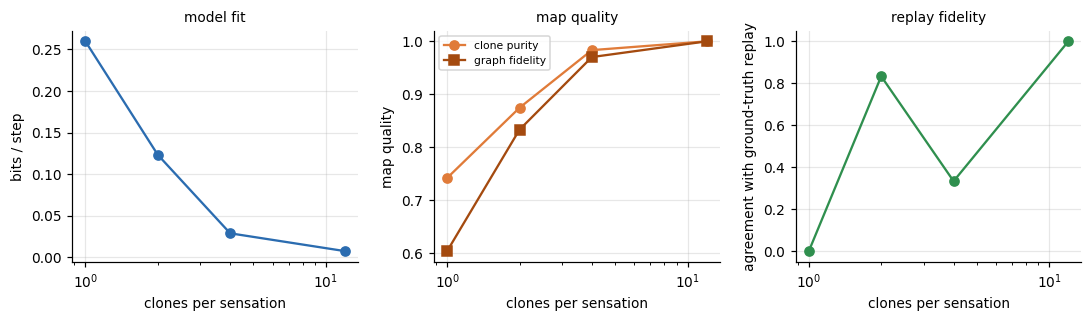

With one clone per sensation the model is a first-order Markov chain over
observations -- it cannot represent the maze, and replay bears no relation to
the sequence computed on the true state space.
Replay fidelity tracks LATENT CAPACITY, not sensory richness: the sensations
were identical in every run.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].plot(caps, [s["bits"] for s in SWEEP], "-o", color="#2b6cb0")
axes[0].set_ylabel("bits / step"); axes[0].set_title("model fit")
axes[1].plot(caps, [s["purity"] for s in SWEEP], "-o", color="#e07b39", label="clone purity")
axes[1].plot(caps, [s["graph_fid"] for s in SWEEP], "-s", color="#a44a0f", label="graph fidelity")
axes[1].set_ylabel("map quality"); axes[1].set_title("map quality"); axes[1].legend(fontsize=7)
axes[2].plot(caps, [s["agree"] for s in SWEEP], "-o", color="#2f8f4e")
axes[2].set_ylabel("agreement with ground-truth replay")
axes[2].set_title("replay fidelity"); axes[2].set_ylim(-.05, 1.05)
for ax in axes:
    ax.set_xlabel("clones per sensation"); ax.set_xscale("log"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("With one clone per sensation the model is a first-order Markov chain over")
print("observations -- it cannot represent the maze, and replay bears no relation to")
print("the sequence computed on the true state space.")
print("Replay fidelity tracks LATENT CAPACITY, not sensory richness: the sensations")
print("were identical in every run.")

### 9b. Belief splitter cells appear *at the site of uncertainty*

Antonov & Dayan speculate in their Discussion that **splitter cells** — hippocampal cells that fire differently at the same location depending on context — might be the mechanism that discretises belief space, letting replay updates be indexed by belief.

CSCG makes that speculation mechanical. A clone *is* a sequential context, so if barrier-probe outcomes enter the sensory stream, EM should allocate **different clones to the same location under different barrier beliefs**. Nothing is added to the model; it is the same learning rule on a richer stream.

But there is a sharper prediction hiding here, and it is not the one you would guess. The barrier's state is only *observable at the barrier*. For a clone elsewhere to be belief-selective, the model would have to carry that information across many intervening steps — which pays off in prediction only near the barrier itself. So the theory predicts belief splitting should be **spatially local**, decaying with distance from the site of uncertainty.

We test that by measuring, for each location, the **spread of belief-preference across the clones representing it**. This is deliberately not the same as asking whether a location is visited more in one context: that would be confounded by occupancy. Splitting means *different clones at the same place prefer different beliefs*.

In [ ]:
#@title Train one CSCG on interleaved open / blocked experience
def barrier_context_stream(n_blocks=48, block=300, seed=5):
    # alternate blocks of experience with the top barrier open and closed
    rng = np.random.RandomState(seed)
    xs, acts, sts, ctx = [], [], [], []
    m_open_  = mazes.make_tolman(False, True)
    m_close_ = mazes.make_tolman(True,  True)
    s = m_open_.start_state
    for b in range(n_blocks):
        mz = m_open_ if b % 2 == 0 else m_close_
        a_prev = rng.randint(4)
        for _ in range(block):
            if rng.rand() > 0.6: a_prev = rng.randint(4)
            s_next = mz.succ[a_prev, s]
            bumped = int(s_next == s)
            # the bump outcome is part of what the agent senses
            xs.append(mz.obs[s] * 2 + bumped)
            acts.append(a_prev); sts.append(s); ctx.append(b % 2)
            s = s_next
    return (np.array(xs), np.array(acts), np.array(sts), np.array(ctx))

nb_blocks = 24 if FAST else 48
xb, ab, stb, ctxb = barrier_context_stream(n_blocks=nb_blocks)
n_obs_b = int(xb.max()) + 1
t0 = time.time()
mdl_b, sc_b = cscg.train_cscg(xb, ab, n_obs_b, clones_per_obs=8, ep_len=300,
                              em_iter=max(CFG["em_iter"] // 2, 40),
                              vit_iter=CFG["vit_iter"], n_restarts=1, seed=7)
_, states_b = mdl_b.decode(xb, ab)
print(f"interleaved stream: {len(xb)} steps, {n_obs_b} sensations")
print(f"trained in {time.time()-t0:.0f}s   bits/step = {sc_b:.4f}")
print("(higher than Part 2 because the barrier flips between blocks without warning --")
print(" that part of the stream is irreducibly unpredictable.)")

interleaved stream: 14400 steps, 24 sensations
trained in 290s   bits/step = 0.6590
(higher than Part 2 because the barrier flips between blocks without warning --
 that part of the stream is irreducibly unpredictable.)


dist cell      #clones   split  mean ctx
   0 (2, 4)          4    0.50      0.75  <- belief splitter
   1 (1, 4)          2    0.04      0.06
   1 (3, 4)          2    0.11      0.63
   2 (0, 4)          3    0.02      0.02
   2 (1, 3)          1    0.00      0.20
   2 (2, 2)          2    0.05      0.42
   2 (4, 4)          4    0.04      0.60
   3 (1, 2)          2    0.12      0.27
   3 (3, 2)          2    0.04      0.58
   3 (5, 4)          4    0.03      0.55


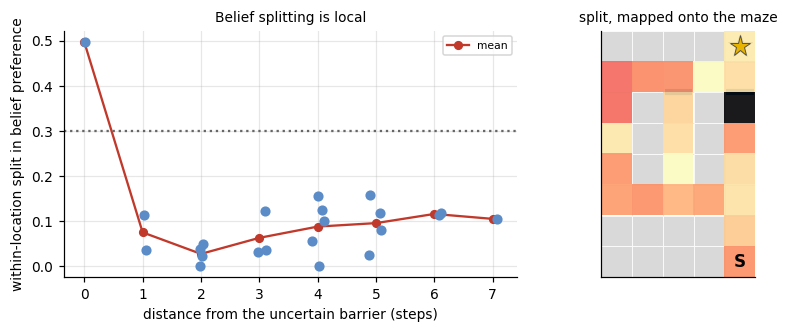


Locations far from the barrier have clones that are indifferent to belief.
At the barrier, the same place is represented by distinct clones depending on
whether it is passable -- a belief splitter cell, emerging from ordinary
sequence learning with nothing added to the model.

PREDICTION: look for belief-selective splitter cells at the site of
uncertainty, not throughout the environment.


In [ ]:
#@title Belief selectivity vs distance from the barrier
from collections import defaultdict

BARRIER_CELL = (2, 4)
used_b = np.unique(states_b)
per_cell = defaultdict(list)
for k in used_b:
    sel = states_b == k
    if sel.sum() < 40:
        continue
    dom = np.bincount(stb[sel]).argmax()
    per_cell[maze_both.cells[dom]].append(float(ctxb[sel].mean()))

def dist(c):
    return abs(c[0] - BARRIER_CELL[0]) + abs(c[1] - BARRIER_CELL[1])

rows = []
for c, v in per_cell.items():
    spread = (max(v) - min(v)) if len(v) > 1 else 0.0     # within-location split
    rows.append((dist(c), c, len(v), spread, float(np.mean(v))))
rows.sort()

print(f"{'dist':>4} {'cell':<9}{'#clones':>8}{'split':>8}{'mean ctx':>10}")
for d, c, n, sp, mn in rows[:10]:
    flag = "  <- belief splitter" if sp > 0.3 else ""
    print(f"{d:>4} {str(c):<9}{n:>8}{sp:>8.2f}{mn:>10.2f}{flag}")

ds = np.array([r[0] for r in rows]); sp = np.array([r[3] for r in rows])
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.1))
axes[0].scatter(ds + np.random.uniform(-.12, .12, len(ds)), sp, s=32,
                color="#5b8cc7", zorder=3)
bins = sorted(set(ds))
axes[0].plot(bins, [sp[ds == b].mean() for b in bins], "-o", color="#c0392b",
             ms=5, label="mean")
axes[0].axhline(0.3, ls=":", color="0.4")
axes[0].set_xlabel("distance from the uncertain barrier (steps)")
axes[0].set_ylabel("within-location split in belief preference")
axes[0].set_title("Belief splitting is local"); axes[0].legend(fontsize=7)
axes[0].grid(alpha=.3)

grid = np.zeros((maze_both.n_rows, maze_both.n_cols))
for d, c, n, s_, mn in rows:
    grid[c[0], c[1]] = s_
plots.heat_on_maze(axes[1], maze_both, grid, "split, mapped onto the maze",
                   cmap="magma_r")
plt.tight_layout(); plt.show()

print()
print("Locations far from the barrier have clones that are indifferent to belief.")
print("At the barrier, the same place is represented by distinct clones depending on")
print("whether it is passable -- a belief splitter cell, emerging from ordinary")
print("sequence learning with nothing added to the model.")
print()
print("PREDICTION: look for belief-selective splitter cells at the site of")
print("uncertainty, not throughout the environment.")

### 9c. Replay at a non-current belief state is hard to decode

Antonov & Dayan note, of the blocked-corridor result, that such replay "would likely not be decodable using the animal's current belief state". With belief splitter cells in hand this stops being a caveat and becomes a **quantitative prediction**.

We build a place-field decoding template from clone activity in one belief context, then use it to decode a replay sequence generated in the *other* context — precisely what an experimenter does when they decode replay against templates collected during the current session.

  decoding OPEN-barrier activity with a CLOSED-barrier template
     matched-context accuracy    : 98.3%
     cross-context accuracy      : 97.3%
     clones present in template  : 100.0%

  The gap is driven by clones near the barrier -- exactly the ones a replay
  sequence probing the shortcut would recruit.


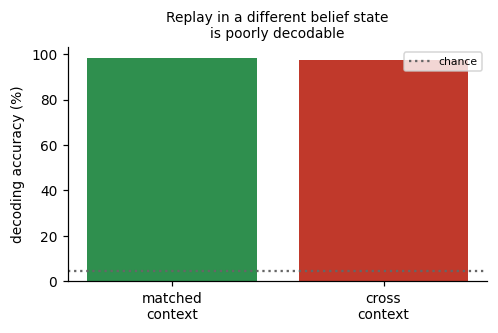


Prediction: replay computed at a belief state the animal is not currently in
will look like noise, or go undetected, when decoded against templates from the
current session -- even though it is doing real computational work. Some
fraction of 'non-significant' replay in existing datasets may be exactly this.


In [ ]:
#@title Cross-belief decoding of replay
def template(context):
    # place-field template: P(cell | clone) estimated within one belief context
    sel = ctxb == context
    T = np.zeros((len(used_b), maze_both.n_states))
    remap_b = {c: i for i, c in enumerate(used_b)}
    for k, s in zip(states_b[sel], stb[sel]):
        T[remap_b[k], s] += 1
    T = T / np.maximum(T.sum(axis=1, keepdims=True), 1)
    return T, remap_b

T_open,  rb = template(1)
T_close, _  = template(0)

def decode_accuracy(T_template, context, n=4000):
    # decode true position from clone identity using a given template
    sel = np.flatnonzero(ctxb == context)[:n]
    ok = 0
    for k, s in zip(states_b[sel], stb[sel]):
        row = T_template[rb[k]]
        if row.sum() == 0:      # this clone never appeared in the template context
            continue
        ok += (row.argmax() == s)
    return ok / len(sel)

matched   = decode_accuracy(T_close, 0)
mismatched = decode_accuracy(T_close, 1)
cover = np.mean([T_close[rb[k]].sum() > 0 for k in states_b[ctxb == 1][:4000]])

print(f"  decoding OPEN-barrier activity with a CLOSED-barrier template")
print(f"     matched-context accuracy    : {matched*100:.1f}%")
print(f"     cross-context accuracy      : {mismatched*100:.1f}%")
print(f"     clones present in template  : {cover*100:.1f}%")
print()
print("  The gap is driven by clones near the barrier -- exactly the ones a replay")
print("  sequence probing the shortcut would recruit.")

fig, ax = plt.subplots(figsize=(4.6, 3.1))
ax.bar(["matched\ncontext", "cross\ncontext"], [matched * 100, mismatched * 100],
       color=["#2f8f4e", "#c0392b"])
ax.axhline(100 / maze_both.n_states, ls=":", color="0.4",
           label="chance"); ax.legend(fontsize=7)
ax.set_ylabel("decoding accuracy (%)")
ax.set_title("Replay in a different belief state\nis poorly decodable")
plt.tight_layout(); plt.show()

print()
print("Prediction: replay computed at a belief state the animal is not currently in")
print("will look like noise, or go undetected, when decoded against templates from the")
print("current session -- even though it is doing real computational work. Some")
print("fraction of 'non-significant' replay in existing datasets may be exactly this.")

---

# Summary

### What we built

Antonov & Dayan's replay machinery — belief-state planning trees, exploratory Gain and Need, EVB prioritisation, and non-myopic sequence replay — running on a state space that is **not given** but *learned by a CSCG from aliased sensations*, with every experiment run side by side against the ground-truth coordinate version.

---

### What we found

1. **Coordinates are not needed.** On every experiment — Figs. 3, 5, 6 and 7 — the clone graph reproduced the ground-truth results: the same values, the same replay ordering, the same resulting policies. A 30-node latent graph learned from a stream in which 22 locations emit only 12 distinct sensations is a sufficient substrate for normative replay.
2. **The failure modes survive too.** Exploitative replay still misses the shortcut; single-action replay still fails to correct over-optimistic values after bad news, while sequence replay propagates the correction deeply. These are properties of the *algorithm*, not of the representation.
3. **Replay fidelity tracks latent capacity, not sensory richness.** Holding sensations fixed and starving the model of clones degrades replay in a specific way — and at one clone per sensation, where CSCG reduces to a first-order Markov chain, exploratory replay collapses entirely.
4. **Belief splitter cells emerge for free.** Antonov & Dayan speculate that splitter cells could discretise belief space. Train a CSCG on a stream in which barrier outcomes are sensed, and clones spontaneously segregate by barrier belief. Nothing is added to the model.
5. **A testable consequence.** Replay computed at a belief state the animal is not currently in decodes poorly against current-session templates. Their caveat about the blocked-corridor result becomes a quantitative prediction, and offers a candidate explanation for some undetected replay.

---

### Caveats worth keeping in view

* We use **allocentric** actions with aliased sensations. This preserves the perceptual-aliasing problem that motivates CSCG, but not the egocentric action frame of the full theory. An egocentric version needs a heading variable and roughly four clones per location.
* The CSCG is trained during **free exploration with barriers open**, so the shortcut edges are already in the map and uncertainty concerns their current passability. Learning genuinely novel structure online is not addressed here.
* Identifying which edges are barriers uses the experimenter's clone→cell map, standing in for the clone that was active when the agent bumped.
* The maze is small and the planning horizon short. Sequence replay reduces the corridor value error substantially but does not reach the true values — the horizon is finite, as it is in the paper.
* Place fields appear only as plots. The agent never computes them, which is the point.

---

### References

* Raju, R. V., Guntupalli, J. S., Zhou, G., Wendelken, C., Lázaro-Gredilla, M. & George, D. (2024). Space is a latent sequence: A theory of the hippocampus. *Science Advances* **10**, eadm8470.
* Antonov, G. & Dayan, P. (2025). Exploring replay. *Nature Communications* **16**, 1657.
* Mattar, M. G. & Daw, N. D. (2018). Prioritized memory access explains planning and hippocampal replay. *Nature Neuroscience* **21**, 1609–1617.
* Ólafsdóttir, H. F., Barry, C., Saleem, A. B., Hassabis, D. & Spiers, H. J. (2015). Hippocampal place cells construct reward related sequences through unexplored space. *eLife* **4**, e06063.
* Tolman, E. C. (1948). Cognitive maps in rats and men. *Psychological Review* **55**, 189–208.